# Eastern Morocco Anthropogenic Pressure
## Step 0 — Input audit, geometry cleaning, overlap review, and AOI clipping

This notebook deliberately stops **before** constructing distance surfaces, density rasters, annual layers, domain scores, or a composite Human Pressure Index. Its purposes are to:

1. locate and inventory every available vector source;
2. inspect layers, fields, feature counts, geometry types, CRS, and key categories;
3. repair basic geometry problems without discarding ecological information;
4. identify within-layer duplicates and major cross-layer overlap;
5. create exact Eastern Morocco clips for review;
6. create a 5-km context clip for later distance and moving-window calculations;
7. document which datasets are independent inputs and which are derived training products.

### Important dataset-use rules

- **Road lines** are the primary road-access source. Road polygons are retained as an auxiliary representation and are not merged blindly with the lines.
- **Railway lines** are the primary railway source. Railway polygons are retained mainly for stations, yards, platforms, or railway land.
- **Full HOTOSM building footprints** are the primary recent building source.
- `Eastern_Morocco_BuiltUp_Candidates_2025.gpkg` is derived from the building footprints and spatially filtered for habitat-classification training. It must not be treated as an independent human-pressure source or added to the full building layer.
- Cultivated training polygons produced from the Al Baten and Bouarfa anthropization layers are also derived training data. Retain them for documentation and habitat-map training, but avoid counting both the raw and derived layers in one pressure index.
- Exact AOI clips are useful for visual review and summaries. The **5-km context clips** must be retained for later distance and 5-km neighborhood calculations, otherwise pressure near the AOI edge will be underestimated.


## 0. Environment

Recommended installation if packages are missing:

```bash
conda install -c conda-forge geopandas pyogrio shapely pandas numpy matplotlib jupyter
```

The workflow uses `pyogrio` when available because its bounding-box filter avoids loading the complete Morocco-wide buildings layer into memory.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Iterable
import json
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import pyogrio
except ImportError:
    pyogrio = None

try:
    from shapely import make_valid
except ImportError:  # compatibility with older Shapely versions
    from shapely.validation import make_valid

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

print("GeoPandas:", gpd.__version__)
print("Pyogrio:", getattr(pyogrio, "__version__", "not installed"))


GeoPandas: 1.1.4
Pyogrio: 0.13.0


## 1. Project paths and dataset registry

A HOTOSM path may point either to the `.shp` itself or to the extracted folder containing it. The resolver below selects a single unambiguous vector file and reports ambiguity rather than silently choosing the wrong file.

Check two naming inconsistencies from the earlier draft:

- use a closing quote/path component for the road path;
- confirm whether the habitat folder is named `Habitat mapping` or `Habitat_mapping`;
- confirm whether the temporal field source is truly `Anthropization_2015_2025.shp`, because the intended study period was previously described as 2008–2024.


In [2]:
# -----------------------------------------------------------------------------
# EDIT THIS CELL FIRST
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
)

AOI_PATH = (
    PROJECT_ROOT
    / "Morocco two study areas"
    / "Eastern_Morocco_Working_Area.shp"
)
AOI_LAYER = None

# Main temporal field anthropization source. The audit will report its fields and
# observed year range; do not rely on the filename alone.
ANTHRO_PATH = (
    PROJECT_ROOT
    / "Reneco"
    / "GIS Data"
    / "Anthropization_2015_2025"
    / "Anthropization_2015_2025.shp"
)
ANTHRO_LAYER = None

HOTOSM_ROOT = PROJECT_ROOT / "Habitat mapping" / "build-up"

# Folder paths are intentional. The resolver will find the contained .shp.
ROADS_LINES_PATH = HOTOSM_ROOT / "hotosm_mar_roads_lines_shp"
ROADS_POLYGONS_PATH = HOTOSM_ROOT / "hotosm_mar_roads_polygons_shp"
BUILDINGS_PATH = HOTOSM_ROOT / "hotosm_mar_buildings_polygons_shp"
PLACES_POLYGONS_PATH = HOTOSM_ROOT / "hotosm_mar_populated_places_polygons_shp"
RAILWAYS_LINES_PATH = HOTOSM_ROOT / "hotosm_mar_railways_lines_shp"
RAILWAYS_POLYGONS_PATH = HOTOSM_ROOT / "hotosm_mar_railways_polygons_shp"

BUILTUP_CANDIDATES_PATH = (
    HOTOSM_ROOT
    / "Eastern_Morocco_BuiltUp_Candidates_2025.gpkg"
)

# Optional raw/derived cultivation sources created in the habitat workflow.
ANTHRO_EXTRACT_DIR = (
    PROJECT_ROOT
    / "Reneco"
    / "GIS Data"
    / "Extract data Yuwen"
    / "Shapefiles"
    / "anthropisation"
)

ALBATEN_FARMS_PATH = ANTHRO_EXTRACT_DIR / "Al_Baten_occupation_Farms_20240621.shp"
BOUARFA_ANTHRO_PATH = ANTHRO_EXTRACT_DIR / "Bouarfa_anthropized_land_1_2024.shp"
CULTIVATED_TRAINING_PATH = (
    ANTHRO_EXTRACT_DIR
    / "Eastern_Morocco_Cultivated_Training_2024.gpkg"
)

# Annual habitat maps are not read in this audit, but keep the path consistent.
HABITAT_RASTER_TEMPLATE = (
    PROJECT_ROOT
    / "Habitat mapping"
    / "Annual_maps"
    / "EM_Habitat_{year}.tif"
)

TARGET_CRS = "EPSG:32630"       # UTM Zone 30N; verify against the AOI
CONTEXT_BUFFER_M = 5_000         # supports later 5-km distance/neighborhood metrics

OUTPUT_DIR = (
    PROJECT_ROOT
    / "Human footprint"
    / "00_input_audit"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_AOI_GPKG = OUTPUT_DIR / "EM_HumanPressure_inputs_AOI_clean.gpkg"
OUT_CONTEXT_GPKG = OUTPUT_DIR / "EM_HumanPressure_inputs_context5km_clean.gpkg"
OUT_INVENTORY_CSV = OUTPUT_DIR / "EM_HumanPressure_input_inventory.csv"
OUT_SCHEMA_CSV = OUTPUT_DIR / "EM_HumanPressure_input_schema.csv"
OUT_VALUES_CSV = OUTPUT_DIR / "EM_HumanPressure_key_value_counts.csv"
OUT_OVERLAP_CSV = OUTPUT_DIR / "EM_HumanPressure_overlap_review.csv"
OUT_DECISIONS_CSV = OUTPUT_DIR / "EM_HumanPressure_dataset_decisions.csv"

print("Output directory:", OUTPUT_DIR)


Output directory: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\00_input_audit


In [3]:
@dataclass(frozen=True)
class DatasetSpec:
    key: str
    path: Path | None
    layer: str | None
    expected_family: str | None
    required: bool
    status: str
    intended_use: str
    caution: str


DATASET_SPECS = [
    DatasetSpec(
        key="anthropization_main",
        path=ANTHRO_PATH,
        layer=ANTHRO_LAYER,
        expected_family=None,
        required=True,
        status="primary_temporal",
        intended_use="Temporal field evidence; retain subtypes and dates separately.",
        caution="Survey effort and temporal meaning must be inspected before annualization.",
    ),
    DatasetSpec(
        key="roads_lines",
        path=ROADS_LINES_PATH,
        layer=None,
        expected_family="line",
        required=True,
        status="primary",
        intended_use="Road/track distance, class-specific accessibility, and line density.",
        caution="Current OSM snapshot; mapping date is not construction date.",
    ),
    DatasetSpec(
        key="roads_polygons",
        path=ROADS_POLYGONS_PATH,
        layer=None,
        expected_family="polygon",
        required=False,
        status="auxiliary",
        intended_use="Road-surface areas, plazas, parking, or special transport polygons after review.",
        caution="May spatially duplicate road lines; do not add both representations as separate pressure counts.",
    ),
    DatasetSpec(
        key="buildings",
        path=BUILDINGS_PATH,
        layer=None,
        expected_family="polygon",
        required=True,
        status="primary_recent_snapshot",
        intended_use="Recent building footprint, density, clustering, and settlement proximity.",
        caution="No annual construction dates; incomplete OSM coverage is possible.",
    ),
    DatasetSpec(
        key="populated_places_polygons",
        path=PLACES_POLYGONS_PATH,
        layer=None,
        expected_family="polygon",
        required=True,
        status="primary_recent_snapshot",
        intended_use="Settlement extent, type, and distance to mapped populated places.",
        caution="Small places mapped only as points will be absent unless the point layer is added later.",
    ),
    DatasetSpec(
        key="railways_lines",
        path=RAILWAYS_LINES_PATH,
        layer=None,
        expected_family="line",
        required=False,
        status="primary_if_present",
        intended_use="Distance to active or mapped railway corridors.",
        caution="Inspect railway type/status; abandoned, proposed, and service lines should not be treated equally.",
    ),
    DatasetSpec(
        key="railways_polygons",
        path=RAILWAYS_POLYGONS_PATH,
        layer=None,
        expected_family="polygon",
        required=False,
        status="auxiliary",
        intended_use="Stations, yards, platforms, or railway land after attribute review.",
        caution="May overlap railway lines; avoid double weighting.",
    ),
    DatasetSpec(
        key="builtup_all_candidates",
        path=BUILTUP_CANDIDATES_PATH,
        layer="builtup_all_candidates",
        expected_family="polygon",
        required=False,
        status="derived_training",
        intended_use="Audit/reference for the habitat-classification candidate workflow.",
        caution="Derived from buildings; exclude as an independent HPI input.",
    ),
    DatasetSpec(
        key="builtup_selected",
        path=BUILTUP_CANDIDATES_PATH,
        layer="builtup_selected",
        expected_family="polygon",
        required=False,
        status="derived_training_subset",
        intended_use="Selected habitat-training examples and visual validation only.",
        caution="Spatially sampled subset; never use as building-pressure coverage.",
    ),
    DatasetSpec(
        key="albaten_farms_2024_raw",
        path=ALBATEN_FARMS_PATH,
        layer=None,
        expected_family="polygon",
        required=False,
        status="raw_land_transformation",
        intended_use="Raw 2024 cultivated/occupation evidence for Al Baten.",
        caution="May be duplicated in the cultivated training GeoPackage.",
    ),
    DatasetSpec(
        key="bouarfa_anthropized_2024_raw",
        path=BOUARFA_ANTHRO_PATH,
        layer=None,
        expected_family="polygon",
        required=False,
        status="raw_land_transformation",
        intended_use="Raw 2024 anthropized/cultivated evidence for Bouarfa.",
        caution="May be duplicated in the cultivated training GeoPackage.",
    ),
    DatasetSpec(
        key="cultivated_albaten_2024_derived",
        path=CULTIVATED_TRAINING_PATH,
        layer="albaten_farms_2024",
        expected_family="polygon",
        required=False,
        status="derived_training",
        intended_use="Documented habitat-training source.",
        caution="Duplicate of a cleaned raw source; do not count twice.",
    ),
    DatasetSpec(
        key="cultivated_bouarfa_2024_derived",
        path=CULTIVATED_TRAINING_PATH,
        layer="bouarfa_cultivated_2024",
        expected_family="polygon",
        required=False,
        status="derived_training",
        intended_use="Documented habitat-training source.",
        caution="Duplicate of a cleaned raw source; do not count twice.",
    ),
    DatasetSpec(
        key="cultivated_combined_2024_derived",
        path=CULTIVATED_TRAINING_PATH,
        layer="cultivated_combined",
        expected_family="polygon",
        required=False,
        status="derived_training_combined",
        intended_use="Combined habitat-training layer and visual reference.",
        caution="Derived from the two raw cultivation sources; exclude from independent pressure counts.",
    ),
]

DECISIONS = pd.DataFrame([asdict(s) for s in DATASET_SPECS])[
    ["key", "status", "intended_use", "caution"]
]
DECISIONS.to_csv(OUT_DECISIONS_CSV, index=False)
display(DECISIONS)


,key,status,intended_use,caution
0,anthropization_main,primary_temporal,Temporal field evidence; retain subtypes and dates separately.,Survey effort and temporal meaning must be inspected before annualization.
1,roads_lines,primary,"Road/track distance, class-specific accessibility, and line density.",Current OSM snapshot; mapping date is not construction date.
2,roads_polygons,auxiliary,"Road-surface areas, plazas, parking, or special transport polygons after review.",May spatially duplicate road lines; do not add both representations as separate pressure counts.
3,buildings,primary_recent_snapshot,"Recent building footprint, density, clustering, and settlement proximity.",No annual construction dates; incomplete OSM coverage is possible.
4,populated_places_polygons,primary_recent_snapshot,"Settlement extent, type, and distance to mapped populated places.",Small places mapped only as points will be absent unless the point layer is added later.
5,railways_lines,primary_if_present,Distance to active or mapped railway corridors.,"Inspect railway type/status; abandoned, proposed, and service lines should not be treated equally."
6,railways_polygons,auxiliary,"Stations, yards, platforms, or railway land after attribute review.",May overlap railway lines; avoid double weighting.
7,builtup_all_candidates,derived_training,Audit/reference for the habitat-classification candidate workflow.,Derived from buildings; exclude as an independent HPI input.
8,builtup_selected,derived_training_subset,Selected habitat-training examples and visual validation only.,Spatially sampled subset; never use as building-pressure coverage.
9,albaten_farms_2024_raw,raw_land_transformation,Raw 2024 cultivated/occupation evidence for Al Baten.,May be duplicated in the cultivated training GeoPackage.


## 2. Path, layer, and source metadata audit

This step does not read full national datasets. It resolves files, lists GeoPackage layers, and reads lightweight GDAL metadata where possible.


In [4]:
VECTOR_SUFFIXES = {".shp", ".gpkg", ".geojson", ".json", ".fgb", ".parquet"}


def resolve_vector_path(path: Path | str | None) -> Path | None:
    """Resolve a file path or a directory containing one unambiguous vector file."""
    if path is None:
        return None

    path = Path(path)
    if path.is_file():
        return path

    if not path.exists():
        return None

    if not path.is_dir():
        return None

    candidates = sorted(
        p for p in path.iterdir()
        if p.is_file() and p.suffix.lower() in VECTOR_SUFFIXES
    )

    if not candidates:
        return None

    if len(candidates) == 1:
        return candidates[0]

    # Prefer the conventional file whose stem exactly matches the folder name.
    exact = [p for p in candidates if p.stem.casefold() == path.name.casefold()]
    if len(exact) == 1:
        return exact[0]

    # Prefer a single shapefile over side products in an extracted HOTOSM folder.
    shapefiles = [p for p in candidates if p.suffix.lower() == ".shp"]
    if len(shapefiles) == 1:
        return shapefiles[0]

    choices = "\n  - ".join(str(p) for p in candidates)
    raise RuntimeError(
        f"More than one vector file was found in {path}. "
        f"Set an exact file path in the configuration cell:\n  - {choices}"
    )


def available_layers(path: Path | None) -> list[str]:
    if path is None or not path.exists():
        return []
    if path.suffix.lower() != ".gpkg":
        return [path.stem]
    if pyogrio is not None:
        return [str(row[0]) for row in pyogrio.list_layers(path)]
    import fiona
    return list(fiona.listlayers(path))


def read_info(path: Path | None, layer: str | None = None) -> dict[str, Any]:
    if path is None or not path.exists() or pyogrio is None:
        return {}
    try:
        return dict(pyogrio.read_info(path, layer=layer))
    except Exception as exc:
        return {"metadata_error": str(exc)}


path_rows = []
for spec in DATASET_SPECS:
    try:
        resolved = resolve_vector_path(spec.path)
        layers = available_layers(resolved)
        layer_exists = (
            resolved is not None
            and resolved.exists()
            and (spec.layer is None or spec.layer in layers)
        )
        info = read_info(resolved, spec.layer if layer_exists else None)
        path_rows.append({
            "dataset": spec.key,
            "required": spec.required,
            "requested_path": str(spec.path) if spec.path is not None else None,
            "resolved_path": str(resolved) if resolved is not None else None,
            "file_exists": bool(resolved is not None and resolved.exists()),
            "requested_layer": spec.layer,
            "layer_exists": layer_exists,
            "available_layers": "; ".join(layers),
            "source_crs": info.get("crs"),
            "source_geometry_type": info.get("geometry_type"),
            "source_feature_count": info.get("features"),
            "path_error": None,
        })
    except Exception as exc:
        path_rows.append({
            "dataset": spec.key,
            "required": spec.required,
            "requested_path": str(spec.path) if spec.path is not None else None,
            "resolved_path": None,
            "file_exists": False,
            "requested_layer": spec.layer,
            "layer_exists": False,
            "available_layers": None,
            "source_crs": None,
            "source_geometry_type": None,
            "source_feature_count": None,
            "path_error": str(exc),
        })

path_audit = pd.DataFrame(path_rows)
display(path_audit)

missing_required = path_audit.loc[
    path_audit["required"] & ~path_audit["layer_exists"],
    ["dataset", "requested_path", "path_error"],
]
if not missing_required.empty:
    print("\nRequired sources that need path correction:")
    display(missing_required)
else:
    print("\nAll required source paths/layers were resolved.")


,dataset,required,requested_path,resolved_path,file_exists,requested_layer,layer_exists,available_layers,source_crs,source_geometry_type,source_feature_count,path_error
0,anthropization_main,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Anthropization_2015_2025\Anthropization_2015_2025.shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Anthropization_2015_2025\Anthropization_2015_2025.shp,True,None,True,Anthropization_2015_2025,EPSG:32630,Polygon,1901,None
1,roads_lines,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_lines_shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_lines_shp\hotosm_mar_roads_lines_shp.shp,True,None,True,hotosm_mar_roads_lines_shp,EPSG:4326,LineString,851069,None
2,roads_polygons,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_polygons_shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_polygons_shp\hotosm_mar_roads_polygons_shp.shp,True,None,True,hotosm_mar_roads_polygons_shp,EPSG:4326,Polygon,7623,None
3,buildings,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp\hotosm_mar_buildings_polygons_s...,True,None,True,hotosm_mar_buildings_polygons_shp,EPSG:4326,Polygon,1492048,None
4,populated_places_polygons,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_polygons_shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_polygons_shp\hotosm_mar_populated_pla...,True,None,True,hotosm_mar_populated_places_polygons_shp,EPSG:4326,Polygon,37420,None
5,railways_lines,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_lines_shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_lines_shp\hotosm_mar_railways_lines_shp.shp,True,None,True,hotosm_mar_railways_lines_shp,EPSG:4326,LineString,3266,None
6,railways_polygons,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_polygons_shp,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_polygons_shp\hotosm_mar_railways_polygons_shp...,True,None,True,hotosm_mar_railways_polygons_shp_poly,EPSG:4326,Polygon,14,None
7,builtup_all_candidates,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg,True,builtup_all_candidates,False,builtup_selected,EPSG:32630,Polygon,107,None
8,builtup_selected,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg,True,builtup_selected,True,builtup_selected,EPSG:32630,Polygon,107,None
9,albaten_farms_2024_raw,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Al_Baten_occupation_Farms_202...,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Al_Baten_occupation_Farms_202...,True,None,True,Al_Baten_occupation_Farms_20240621,EPSG:4326,Polygon Z,15


All required source paths/layers were resolved.


### Check the built-up candidate GeoPackage

Your earlier export code contains an indentation issue: `built_candidates.to_file(...)` runs only when the old output already exists. On a first run, the GeoPackage may therefore contain only `builtup_selected`.

The correct export pattern in the habitat notebook is:

```python
if BUILD_OUT.exists():
    BUILD_OUT.unlink()

built_candidates.to_file(
    BUILD_OUT,
    layer="builtup_all_candidates",
    driver="GPKG"
)

built_selected.to_file(
    BUILD_OUT,
    layer="builtup_selected",
    driver="GPKG"
)
```

The next cell reports the currently available layers rather than assuming both exist.


In [8]:
resolved_builtup = resolve_vector_path(BUILTUP_CANDIDATES_PATH)
print("Built-up candidate file:", resolved_builtup)
print("Layers:", available_layers(resolved_builtup))

Built-up candidate file: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg
Layers: ['builtup_selected']


## 3. Geometry utilities and AOI preparation

The cleaning performed here is intentionally conservative:

- remove null and empty geometries;
- repair invalid geometries;
- explode multipart/collection output after repair;
- retain only the expected geometry family for known sources;
- remove zero-length lines and zero-area polygons;
- preserve source attributes;
- report duplicates rather than aggressively dissolving or deleting them.


In [12]:
GEOM_TYPES = {
    "point": {"Point", "MultiPoint"},
    "line": {"LineString", "MultiLineString", "LinearRing"},
    "polygon": {"Polygon", "MultiPolygon"},
}


def geometry_family_from_type(geom_type: str) -> str:
    for family, valid_types in GEOM_TYPES.items():
        if geom_type in valid_types:
            return family
    return "other"


def clean_vector_geometry(
    gdf: gpd.GeoDataFrame,
    expected_family: str | None = None,
) -> tuple[gpd.GeoDataFrame, dict[str, int]]:
    """Conservative geometry QC; returns cleaned data and diagnostics."""
    x = gdf.copy()
    if "geometry" not in x:
        raise ValueError("Input does not have an active geometry column.")

    x["_source_row"] = np.arange(len(x), dtype="int64")

    diagnostics = {
        "features_read_bbox": int(len(x)),
        "null_geometry_removed": int(x.geometry.isna().sum()),
        "empty_geometry_removed": int(x.geometry.apply(
            lambda geom: bool(geom is not None and geom.is_empty)
        ).sum()),
        "invalid_geometry_before": int((
            x.geometry.notna()
            & ~x.geometry.is_empty
            & ~x.geometry.is_valid
        ).sum()),
        "unexpected_geometry_removed": 0,
        "zero_measure_removed": 0,
    }

    x = x.loc[x.geometry.notna()].copy()
    x = x.loc[~x.geometry.is_empty].copy()

    invalid_mask = ~x.geometry.is_valid
    if invalid_mask.any():
        x.loc[invalid_mask, "geometry"] = x.loc[invalid_mask, "geometry"].apply(make_valid)

    x = x.loc[x.geometry.notna()].copy()
    x = x.loc[~x.geometry.is_empty].copy()

    # make_valid can create multipart or GeometryCollection output.
    x = x.explode(index_parts=False, ignore_index=True)
    x = x.loc[x.geometry.notna()].copy()
    x = x.loc[~x.geometry.is_empty].copy()

    if expected_family is not None:
        allowed = GEOM_TYPES[expected_family]
        keep = x.geometry.geom_type.isin(allowed)
        diagnostics["unexpected_geometry_removed"] = int((~keep).sum())
        x = x.loc[keep].copy()

    if expected_family == "polygon":
    # Only test whether geometry has non-zero area.
    # Use Shapely geometry.area directly so this is CRS-independent
    # and does not trigger GeoPandas geographic-CRS warnings.
        keep = x.geometry.apply(
        lambda g: g is not None
        and not g.is_empty
        and g.area > 0
        )

        diagnostics["zero_measure_removed"] = int(
        (~keep).sum()
        )

        x = x.loc[keep].copy()

    elif expected_family == "line":
    # Only test whether geometry has non-zero length.
        keep = x.geometry.apply(
        lambda g: g is not None
        and not g.is_empty
        and g.length > 0
    )

        diagnostics["zero_measure_removed"] = int(
        (~keep).sum()
        )

        x = x.loc[keep].copy()


    diagnostics["invalid_geometry_after"] = int((~x.geometry.is_valid.fillna(False)).sum())
    diagnostics["features_after_geometry_qc"] = int(len(x))

    return x.reset_index(drop=True), diagnostics


def union_geometry(gdf: gpd.GeoDataFrame):
    if hasattr(gdf.geometry, "union_all"):
        return gdf.geometry.union_all()
    return gdf.geometry.unary_union


def read_vector(
    path: Path,
    layer: str | None = None,
    bbox: tuple[float, float, float, float] | None = None,
) -> gpd.GeoDataFrame:
    kwargs: dict[str, Any] = {}
    if layer is not None:
        kwargs["layer"] = layer
    if bbox is not None:
        kwargs["bbox"] = bbox
    if pyogrio is not None:
        kwargs["engine"] = "pyogrio"
    return gpd.read_file(path, **kwargs)


resolved_aoi = resolve_vector_path(AOI_PATH)
if resolved_aoi is None:
    raise FileNotFoundError(f"AOI not found: {AOI_PATH}")

aoi_raw = read_vector(resolved_aoi, layer=AOI_LAYER)
if aoi_raw.crs is None:
    raise ValueError("The AOI has no CRS. Define its CRS before continuing.")

aoi_clean, aoi_qc = clean_vector_geometry(aoi_raw, expected_family="polygon")
aoi_clean = aoi_clean.to_crs(TARGET_CRS)

aoi = gpd.GeoDataFrame(
    {"aoi_name": ["Eastern_Morocco_Working_Area"]},
    geometry=[union_geometry(aoi_clean)],
    crs=TARGET_CRS,
)

aoi_context = aoi.copy()
aoi_context["geometry"] = aoi_context.geometry.buffer(CONTEXT_BUFFER_M)

aoi_wgs84 = aoi.to_crs("EPSG:4326")
minx, miny, maxx, maxy = aoi_wgs84.total_bounds

print("AOI CRS:", aoi.crs)
print("AOI area (km2):", round(float(aoi.geometry.area.iloc[0] / 1e6), 2))
print("AOI WGS84 bounds:", tuple(round(float(v), 5) for v in (minx, miny, maxx, maxy)))
print("Context buffer (m):", CONTEXT_BUFFER_M)
print("AOI geometry QC:", aoi_qc)

if not (-6.5 <= minx <= 0.5 and -6.5 <= maxx <= 0.5):
    warnings.warn(
        "The AOI longitude range is unusual for UTM Zone 30N. Verify TARGET_CRS."
    )


AOI CRS: EPSG:32630
AOI area (km2): 50203.94
AOI WGS84 bounds: (-4.9714, 31.9721, -0.99698, 34.16511)
Context buffer (m): 5000
AOI geometry QC: {'features_read_bbox': 1, 'null_geometry_removed': 0, 'empty_geometry_removed': 0, 'invalid_geometry_before': 0, 'unexpected_geometry_removed': 0, 'zero_measure_removed': 0, 'invalid_geometry_after': 0, 'features_after_geometry_qc': 1}


## 4. Efficient reading, cleaning, and clipping

For large national layers, the code first transforms the 5-km context bounding box into the source CRS and asks GDAL to read only intersecting features. It then performs an exact clip in the common projected CRS.


In [13]:
def source_bbox_for_context(
    source_crs: Any,
    context: gpd.GeoDataFrame,
) -> tuple[float, float, float, float] | None:
    if source_crs is None:
        return None
    try:
        transformed = context.to_crs(source_crs)
        return tuple(float(v) for v in transformed.total_bounds)
    except Exception as exc:
        warnings.warn(f"Could not transform context bbox to source CRS: {exc}")
        return None


def identify_id_field(columns: Iterable[str]) -> str | None:
    normalized = {str(c).strip().casefold(): str(c) for c in columns}
    candidates = [
        "osm_id", "osm_way_id", "osm_node_id", "objectid", "object_id",
        "feature_id", "station_id", "id", "fid",
    ]
    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]
    return None


def duplicate_diagnostics(gdf: gpd.GeoDataFrame) -> dict[str, Any]:
    if gdf.empty:
        return {
            "id_field": None,
            "duplicate_id_features": 0,
            "duplicate_id_values": 0,
            "duplicate_geometry_features": 0,
            "duplicate_geometry_values": 0,
        }

    id_field = identify_id_field(gdf.columns)
    duplicate_id_features = 0
    duplicate_id_values = 0
    if id_field is not None:
        valid = gdf[id_field].notna()
        duplicate_id_features = int(gdf.loc[valid, id_field].duplicated(keep=False).sum())
        duplicate_id_values = int(
            gdf.loc[valid & gdf[id_field].duplicated(keep=False), id_field].nunique()
        )

    geom_wkb = gdf.geometry.to_wkb(hex=True)
    duplicate_geometry_features = int(geom_wkb.duplicated(keep=False).sum())
    duplicate_geometry_values = int(geom_wkb.loc[geom_wkb.duplicated(keep=False)].nunique())

    return {
        "id_field": id_field,
        "duplicate_id_features": duplicate_id_features,
        "duplicate_id_values": duplicate_id_values,
        "duplicate_geometry_features": duplicate_geometry_features,
        "duplicate_geometry_values": duplicate_geometry_values,
    }


def summarize_measure(gdf: gpd.GeoDataFrame) -> dict[str, float | None]:
    if gdf.empty:
        return {
            "total_area_km2": None,
            "median_area_m2": None,
            "total_length_km": None,
            "median_length_m": None,
        }

    families = gdf.geometry.geom_type.map(geometry_family_from_type)
    polygon_mask = families.eq("polygon")
    line_mask = families.eq("line")

    area = gdf.loc[polygon_mask].geometry.area if polygon_mask.any() else pd.Series(dtype=float)
    length = gdf.loc[line_mask].geometry.length if line_mask.any() else pd.Series(dtype=float)

    return {
        "total_area_km2": float(area.sum() / 1e6) if len(area) else None,
        "median_area_m2": float(area.median()) if len(area) else None,
        "total_length_km": float(length.sum() / 1e3) if len(length) else None,
        "median_length_m": float(length.median()) if len(length) else None,
    }


def load_clean_clip(
    spec: DatasetSpec,
    aoi_exact: gpd.GeoDataFrame,
    context: gpd.GeoDataFrame,
) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, dict[str, Any], list[dict[str, Any]]]:
    resolved = resolve_vector_path(spec.path)
    if resolved is None or not resolved.exists():
        raise FileNotFoundError(f"Source not found: {spec.path}")

    layers = available_layers(resolved)
    if spec.layer is not None and spec.layer not in layers:
        raise ValueError(
            f"Layer '{spec.layer}' is missing from {resolved}. Available: {layers}"
        )

    info = read_info(resolved, spec.layer)
    source_crs = info.get("crs")
    bbox = source_bbox_for_context(source_crs, context)

    try:
        raw = read_vector(resolved, layer=spec.layer, bbox=bbox)
    except Exception as exc:
        warnings.warn(
            f"Bounding-box read failed for {spec.key}; reading the full source. Error: {exc}"
        )
        raw = read_vector(resolved, layer=spec.layer)

    if raw.crs is None:
        raise ValueError(
            f"{spec.key} has no CRS. Define the correct source CRS before clipping."
        )

    cleaned, qc = clean_vector_geometry(raw, expected_family=spec.expected_family)
    cleaned = cleaned.to_crs(TARGET_CRS)

    context_clip = gpd.clip(cleaned, context, keep_geom_type=False)
    context_clip, context_qc = clean_vector_geometry(
        context_clip,
        expected_family=spec.expected_family,
    )
    context_clip = context_clip.set_crs(TARGET_CRS, allow_override=True)

    exact_clip = gpd.clip(context_clip, aoi_exact, keep_geom_type=False)
    exact_clip, exact_qc = clean_vector_geometry(
        exact_clip,
        expected_family=spec.expected_family,
    )
    exact_clip = exact_clip.set_crs(TARGET_CRS, allow_override=True)

    # Provenance fields are useful after several layers are stored in one GeoPackage.
    for frame in (context_clip, exact_clip):
        frame["_dataset"] = spec.key
        frame["_src_file"] = resolved.name
        frame["_src_layer"] = spec.layer if spec.layer is not None else ""

    dup = duplicate_diagnostics(exact_clip)
    measure = summarize_measure(exact_clip)

    inventory = {
        "dataset": spec.key,
        "status": spec.status,
        "required": spec.required,
        "resolved_path": str(resolved),
        "source_layer": spec.layer,
        "source_crs": str(raw.crs),
        "target_crs": str(TARGET_CRS),
        "source_feature_count_metadata": info.get("features"),
        "features_read_bbox": qc.get("features_read_bbox"),
        "features_after_geometry_qc": qc.get("features_after_geometry_qc"),
        "features_context5km": int(len(context_clip)),
        "features_aoi": int(len(exact_clip)),
        "null_geometry_removed": qc.get("null_geometry_removed"),
        "empty_geometry_removed": qc.get("empty_geometry_removed"),
        "invalid_geometry_before": qc.get("invalid_geometry_before"),
        "invalid_geometry_after": exact_qc.get("invalid_geometry_after"),
        "unexpected_geometry_removed": qc.get("unexpected_geometry_removed"),
        "zero_measure_removed": qc.get("zero_measure_removed"),
        "geometry_types_aoi": "; ".join(
            f"{k}:{v}" for k, v in exact_clip.geometry.geom_type.value_counts().items()
        ),
        "n_attribute_fields": int(len([c for c in exact_clip.columns if c != "geometry"])),
        **dup,
        **measure,
    }

    schema_rows = []
    for column in exact_clip.columns:
        if column == "geometry":
            continue
        series = exact_clip[column]
        non_null = series.dropna()
        samples = [str(v) for v in non_null.astype(str).drop_duplicates().head(5)]
        schema_rows.append({
            "dataset": spec.key,
            "field": column,
            "dtype": str(series.dtype),
            "non_null": int(series.notna().sum()),
            "n_unique": int(non_null.nunique(dropna=True)),
            "sample_values": " | ".join(samples),
        })

    return exact_clip, context_clip, inventory, schema_rows


In [14]:
aoi_layers: dict[str, gpd.GeoDataFrame] = {}
context_layers: dict[str, gpd.GeoDataFrame] = {}
inventory_rows: list[dict[str, Any]] = []
schema_rows: list[dict[str, Any]] = []
load_errors: list[dict[str, str]] = []

for spec in DATASET_SPECS:
    print(f"Processing: {spec.key}")
    try:
        exact_clip, context_clip, inventory, schema = load_clean_clip(
            spec,
            aoi_exact=aoi,
            context=aoi_context,
        )
        aoi_layers[spec.key] = exact_clip
        context_layers[spec.key] = context_clip
        inventory_rows.append(inventory)
        schema_rows.extend(schema)
        print(
            f"  AOI features: {len(exact_clip):,}; "
            f"context features: {len(context_clip):,}"
        )
    except Exception as exc:
        load_errors.append({"dataset": spec.key, "error": str(exc)})
        print("  SKIPPED:", exc)

inventory = pd.DataFrame(inventory_rows).sort_values("dataset").reset_index(drop=True)
schema = pd.DataFrame(schema_rows).sort_values(["dataset", "field"]).reset_index(drop=True)

inventory.to_csv(OUT_INVENTORY_CSV, index=False)
schema.to_csv(OUT_SCHEMA_CSV, index=False)

display(inventory)

if load_errors:
    print("\nSources not loaded:")
    display(pd.DataFrame(load_errors))


Processing: anthropization_main
  AOI features: 1,903; context features: 1,903
Processing: roads_lines
  AOI features: 11,911; context features: 13,879
Processing: roads_polygons
  AOI features: 67; context features: 79
Processing: buildings
  AOI features: 2,584; context features: 4,889
Processing: populated_places_polygons
  AOI features: 349; context features: 461
Processing: railways_lines
  AOI features: 31; context features: 33
Processing: railways_polygons
  SKIPPED: 'GeometryArray' with dtype geometry does not support reduction 'sum'
Processing: builtup_all_candidates
  SKIPPED: Layer 'builtup_all_candidates' is missing from C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg. Available: ['builtup_selected']
Processing: builtup_selected
  AOI features: 107; context features: 107
Processing: albaten_farms_2024_raw
  AOI features: 153; context features: 153
Processing: bouarfa_anthropized_2024_raw

,dataset,status,required,resolved_path,source_layer,source_crs,target_crs,source_feature_count_metadata,features_read_bbox,features_after_geometry_qc,features_context5km,features_aoi,null_geometry_removed,empty_geometry_removed,invalid_geometry_before,invalid_geometry_after,unexpected_geometry_removed,zero_measure_removed,geometry_types_aoi,n_attribute_fields,id_field,duplicate_id_features,duplicate_id_values,duplicate_geometry_features,duplicate_geometry_values,total_area_km2,median_area_m2,total_length_km,median_length_m
0,albaten_farms_2024_raw,raw_land_transformation,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Al_Baten_occupation_Farms_202...,None,EPSG:4326,EPSG:32630,153,153,153,153,153,0,0,0,0,0,0,Polygon:153,10,None,0,0,0,0,13.978636,32514.443170,NaN,NaN
1,anthropization_main,primary_temporal,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Anthropization_2015_2025\Anthropization_2015_2025.shp,None,EPSG:32630,EPSG:32630,1901,1901,1903,1903,1903,0,0,0,0,0,0,Polygon:1903,10,None,0,0,665,315,155.651759,33118.187309,NaN,NaN
2,bouarfa_anthropized_2024_raw,raw_land_transformation,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Bouarfa_anthropized_land_1_20...,None,EPSG:32630,EPSG:32630,606,606,606,606,606,0,0,0,0,0,0,Polygon:606,11,None,0,0,0,0,43.600643,33383.264167,NaN,NaN
3,buildings,primary_recent_snapshot,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp\hotosm_mar_buildings_polygons_s...,None,EPSG:4326,EPSG:32630,1492048,13963,13965,4889,2584,0,0,0,0,0,0,Polygon:2584,19,osm_id,0,0,0,0,0.655687,131.911209,NaN,NaN
4,builtup_selected,derived_training_subset,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg,builtup_selected,EPSG:32630,EPSG:32630,107,107,107,107,107,0,0,0,0,0,0,Polygon:107,26,None,0,0,0,0,0.483994,2717.337335,NaN,NaN
5,cultivated_albaten_2024_derived,derived_training,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Tr...,albaten_farms_2024,EPSG:32630,EPSG:32630,153,153,153,153,153,0,0,0,0,0,0,Polygon:153,23,None,0,0,0,0,13.978636,32514.443170,NaN,NaN
6,cultivated_bouarfa_2024_derived,derived_training,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Tr...,bouarfa_cultivated_2024,EPSG:32630,EPSG:32630,606,606,606,606,606,0,0,0,0,0,0,Polygon:606,22,None,0,0,0,0,43.600643,33383.264167,NaN,NaN
7,cultivated_combined_2024_derived,derived_training_combined,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Tr...,cultivated_combined,EPSG:32630,EPSG:32630,759,759,759,759,759,0,0,0,0,0,0,Polygon:759,25,None,0,0,0,0,57.579279,32975.733746,NaN,NaN
8,populated_places_polygons,primary_recent_snapshot,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_polygons_shp\hotosm_mar_populated_pla...,None,EPSG:4326,EPSG:32630,37420,1218,1218,461,349,0,0,0,0,0,0,Polygon:349,15,osm_id,10,4,0,0,39.059291,25282.218054,NaN,NaN
9,railways_lines,primary_if_present,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_lines_shp\hotosm_mar_railways_lines_shp.shp,None,EPSG:4326,EPSG:32630,3266,225,225,33,31,0,0,0,0,0,0,LineString:31,17,osm_id,0,0,0,0,NaN,NaN,190.611036,466.083915



Sources not loaded:


,dataset,error
0,railways_polygons,'GeometryArray' with dtype geometry does not support reduction 'sum'
1,builtup_all_candidates,Layer 'builtup_all_candidates' is missing from C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_Bu...


## 5. Attribute review

The following functions inspect likely OSM fields and compact categorical fields. This is where road, railway, building, place, and anthropization classes should be understood **before** recoding them.


In [15]:
PREFERRED_FIELDS = {
    "roads_lines": [
        "highway", "surface", "tracktype", "service", "smoothness",
        "access", "name", "bridge", "tunnel", "osm_id",
    ],
    "roads_polygons": [
        "highway", "surface", "service", "landuse", "amenity", "name", "osm_id",
    ],
    "buildings": [
        "building", "building:use", "amenity", "shop", "industrial",
        "name", "osm_id",
    ],
    "populated_places_polygons": [
        "place", "name", "population", "capital", "admin_level", "osm_id",
    ],
    "railways_lines": [
        "railway", "service", "usage", "status", "operator", "name", "osm_id",
    ],
    "railways_polygons": [
        "railway", "landuse", "public_transport", "amenity", "name", "osm_id",
    ],
}


def case_insensitive_field_lookup(columns: Iterable[str]) -> dict[str, str]:
    return {str(c).strip().casefold(): str(c) for c in columns}


def key_value_counts(
    dataset: str,
    gdf: gpd.GeoDataFrame,
    preferred_fields: list[str] | None = None,
    max_auto_unique: int = 30,
    top_n: int = 25,
) -> pd.DataFrame:
    lookup = case_insensitive_field_lookup(gdf.columns)
    selected: list[str] = []

    for requested in preferred_fields or []:
        actual = lookup.get(requested.casefold())
        if actual is not None and actual not in selected:
            selected.append(actual)

    # Also include compact categorical/text fields, useful for unknown anthropization schemas.
    for column in gdf.columns:
        if column == "geometry" or column.startswith("_") or column in selected:
            continue
        series = gdf[column]
        if (
            pd.api.types.is_object_dtype(series)
            or pd.api.types.is_string_dtype(series)
            or isinstance(series.dtype, pd.CategoricalDtype)
        ):
            n_unique = series.nunique(dropna=True)
            if 0 < n_unique <= max_auto_unique:
                selected.append(column)

    rows = []
    for field in selected:
        counts = (
            gdf[field]
            .astype("string")
            .fillna("<NA>")
            .value_counts(dropna=False)
            .head(top_n)
        )
        for value, count in counts.items():
            rows.append({
                "dataset": dataset,
                "field": field,
                "value": str(value),
                "count": int(count),
                "percent": round(100.0 * int(count) / max(len(gdf), 1), 3),
            })
    return pd.DataFrame(rows)


value_tables = []
for key, gdf in aoi_layers.items():
    if gdf.empty:
        continue
    table = key_value_counts(
        dataset=key,
        gdf=gdf,
        preferred_fields=PREFERRED_FIELDS.get(key, []),
    )
    if not table.empty:
        value_tables.append(table)

value_counts = (
    pd.concat(value_tables, ignore_index=True)
    if value_tables
    else pd.DataFrame(columns=["dataset", "field", "value", "count", "percent"])
)
value_counts.to_csv(OUT_VALUES_CSV, index=False)

# Compact display: top 10 values for each dataset/field.
display(
    value_counts
    .groupby(["dataset", "field"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)


,dataset,field,value,count,percent
0,anthropization_main,Type,Cultivated,1836,96.479
1,anthropization_main,Type,Uncultivated,51,2.680
2,anthropization_main,Type,Restore Ecosystem Activity,16,0.841
3,anthropization_main,Year,2024,616,32.370
4,anthropization_main,Year,2023,479,25.171
...,...,...,...,...,...
368,cultivated_combined_2024_derived,grid_id,G026,18,2.372
369,cultivated_combined_2024_derived,Type,Cultivated,606,79.842
370,cultivated_combined_2024_derived,Type,<NA>,153,20.158
371,cultivated_combined_2024_derived,Year,2024,606,79.842


### Inspect the anthropization temporal fields

This diagnostic searches for likely year/date fields and reports numerical ranges. It does not yet assign persistence rules.


In [16]:
YEAR_NAME_PATTERN = re.compile(r"(^|_)(year|yr|annee|date|start|end|from|to)(_|$)", re.I)


def temporal_field_diagnostics(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    rows = []
    for column in gdf.columns:
        if column == "geometry" or not YEAR_NAME_PATTERN.search(str(column)):
            continue

        series = gdf[column]
        numeric = pd.to_numeric(series, errors="coerce")
        parsed_date = pd.to_datetime(series, errors="coerce")

        years_numeric = numeric.loc[numeric.between(1900, 2100, inclusive="both")]
        years_date = parsed_date.dt.year.dropna()

        rows.append({
            "field": column,
            "dtype": str(series.dtype),
            "non_null": int(series.notna().sum()),
            "numeric_year_min": int(years_numeric.min()) if len(years_numeric) else None,
            "numeric_year_max": int(years_numeric.max()) if len(years_numeric) else None,
            "parsed_date_min": str(parsed_date.min().date()) if parsed_date.notna().any() else None,
            "parsed_date_max": str(parsed_date.max().date()) if parsed_date.notna().any() else None,
            "parsed_year_min": int(years_date.min()) if len(years_date) else None,
            "parsed_year_max": int(years_date.max()) if len(years_date) else None,
        })
    return pd.DataFrame(rows)


anthro = aoi_layers.get("anthropization_main")
if anthro is not None and not anthro.empty:
    print("Anthropization fields:")
    print(list(anthro.columns))
    display(temporal_field_diagnostics(anthro))
else:
    print("The main anthropization layer was not loaded or is empty in the AOI.")


Anthropization fields:
['Type', 'Year', 'Bassin', 'creation_d', 'area_km', 'Area', '_source_row', 'geometry', '_dataset', '_src_file', '_src_layer']


,field,dtype,non_null,numeric_year_min,numeric_year_max,parsed_date_min,parsed_date_max,parsed_year_min,parsed_year_max
0,Year,object,1903,2015,2025,2015-01-01,2025-01-01,2015,2025


## 6. Cross-layer overlap review

These checks answer whether polygon and line representations describe the same mapped infrastructure, and confirm that the built-up candidate layers are nested within the original buildings source.

They are diagnostics only. The workflow does not dissolve or delete cross-layer features automatically.


In [17]:
def nearest_distance_summary(
    source_name: str,
    source: gpd.GeoDataFrame,
    target_name: str,
    target: gpd.GeoDataFrame,
    thresholds_m: tuple[float, ...] = (0, 5, 10, 25, 50),
) -> list[dict[str, Any]]:
    if source.empty or target.empty:
        return [{
            "check": f"{source_name}_to_{target_name}_nearest",
            "metric": "not_computed_empty_layer",
            "value": np.nan,
        }]

    left = source[["geometry"]].reset_index(drop=True).reset_index(names="_source_index")
    right = target[["geometry"]].reset_index(drop=True)

    joined = gpd.sjoin_nearest(
        left,
        right,
        how="left",
        distance_col="distance_m",
    )
    distance = joined.groupby("_source_index")["distance_m"].min()

    rows = [
        {
            "check": f"{source_name}_to_{target_name}_nearest",
            "metric": "n_source_features",
            "value": int(len(source)),
        },
        {
            "check": f"{source_name}_to_{target_name}_nearest",
            "metric": "median_distance_m",
            "value": float(distance.median()),
        },
        {
            "check": f"{source_name}_to_{target_name}_nearest",
            "metric": "p95_distance_m",
            "value": float(distance.quantile(0.95)),
        },
    ]

    for threshold in thresholds_m:
        rows.append({
            "check": f"{source_name}_to_{target_name}_nearest",
            "metric": f"percent_within_{threshold:g}m",
            "value": float(100.0 * distance.le(threshold).mean()),
        })
    return rows


def source_features_per_candidate_summary(
    candidate_name: str,
    candidates: gpd.GeoDataFrame,
    source_name: str,
    source: gpd.GeoDataFrame,
) -> list[dict[str, Any]]:
    if candidates.empty or source.empty:
        return [{
            "check": f"{source_name}_within_{candidate_name}",
            "metric": "not_computed_empty_layer",
            "value": np.nan,
        }]

    left = candidates[["geometry"]].reset_index(drop=True).reset_index(names="_candidate_index")
    right = source[["geometry"]].reset_index(drop=True)
    joined = gpd.sjoin(left, right, how="left", predicate="intersects")

    counts = joined.groupby("_candidate_index")["index_right"].count()
    counts = counts.reindex(range(len(candidates)), fill_value=0)

    return [
        {
            "check": f"{source_name}_within_{candidate_name}",
            "metric": "n_candidate_features",
            "value": int(len(candidates)),
        },
        {
            "check": f"{source_name}_within_{candidate_name}",
            "metric": "percent_candidates_intersecting_source",
            "value": float(100.0 * counts.gt(0).mean()),
        },
        {
            "check": f"{source_name}_within_{candidate_name}",
            "metric": "median_source_features_per_candidate",
            "value": float(counts.median()),
        },
        {
            "check": f"{source_name}_within_{candidate_name}",
            "metric": "mean_source_features_per_candidate",
            "value": float(counts.mean()),
        },
        {
            "check": f"{source_name}_within_{candidate_name}",
            "metric": "max_source_features_per_candidate",
            "value": int(counts.max()),
        },
    ]


overlap_rows: list[dict[str, Any]] = []

if "roads_polygons" in aoi_layers and "roads_lines" in aoi_layers:
    overlap_rows.extend(nearest_distance_summary(
        "roads_polygons", aoi_layers["roads_polygons"],
        "roads_lines", aoi_layers["roads_lines"],
    ))

if "railways_polygons" in aoi_layers and "railways_lines" in aoi_layers:
    overlap_rows.extend(nearest_distance_summary(
        "railways_polygons", aoi_layers["railways_polygons"],
        "railways_lines", aoi_layers["railways_lines"],
    ))

for candidate_key in ("builtup_all_candidates", "builtup_selected"):
    if candidate_key in aoi_layers and "buildings" in aoi_layers:
        overlap_rows.extend(source_features_per_candidate_summary(
            candidate_key,
            aoi_layers[candidate_key],
            "buildings",
            aoi_layers["buildings"],
        ))

overlap_review = pd.DataFrame(overlap_rows)
overlap_review.to_csv(OUT_OVERLAP_CSV, index=False)
display(overlap_review)


,check,metric,value
0,roads_polygons_to_roads_lines_nearest,n_source_features,67.000000
1,roads_polygons_to_roads_lines_nearest,median_distance_m,0.000000
2,roads_polygons_to_roads_lines_nearest,p95_distance_m,4.744311
3,roads_polygons_to_roads_lines_nearest,percent_within_0m,91.044776
4,roads_polygons_to_roads_lines_nearest,percent_within_5m,94.029851
5,roads_polygons_to_roads_lines_nearest,percent_within_10m,97.014925
6,roads_polygons_to_roads_lines_nearest,percent_within_25m,97.014925
7,roads_polygons_to_roads_lines_nearest,percent_within_50m,97.014925
8,buildings_within_builtup_selected,n_candidate_features,107.000000
9,buildings_within_builtup_selected,percent_candidates_intersecting_source,100.000000


## 7. Optional exact-overlap checks for raw and derived cultivation layers

The combined training layers are expected to reproduce cleaned versions of the raw sources. The diagnostic below compares their union areas. A high overlap indicates derivation, not independent corroboration.


In [19]:
def polygon_union_overlap(
    name_a: str,
    a: gpd.GeoDataFrame,
    name_b: str,
    b: gpd.GeoDataFrame,
) -> pd.DataFrame:
    if a.empty or b.empty:
        return pd.DataFrame([{
            "layer_a": name_a,
            "layer_b": name_b,
            "area_a_km2": np.nan,
            "area_b_km2": np.nan,
            "intersection_km2": np.nan,
            "intersection_percent_of_a": np.nan,
            "intersection_percent_of_b": np.nan,
        }])

    geom_a = union_geometry(a)
    geom_b = union_geometry(b)
    area_a = geom_a.area
    area_b = geom_b.area
    inter = geom_a.intersection(geom_b).area

    return pd.DataFrame([{
        "layer_a": name_a,
        "layer_b": name_b,
        "area_a_km2": area_a / 1e6,
        "area_b_km2": area_b / 1e6,
        "intersection_km2": inter / 1e6,
        "intersection_percent_of_a": 100.0 * inter / area_a if area_a > 0 else np.nan,
        "intersection_percent_of_b": 100.0 * inter / area_b if area_b > 0 else np.nan,
    }])


cultivation_overlap_tables = []
comparison_pairs = [
    ("albaten_farms_2024_raw", "cultivated_albaten_2024_derived"),
    ("bouarfa_anthropized_2024_raw", "cultivated_bouarfa_2024_derived"),
]

for raw_key, derived_key in comparison_pairs:
    if raw_key in aoi_layers and derived_key in aoi_layers:
        cultivation_overlap_tables.append(polygon_union_overlap(
            raw_key, aoi_layers[raw_key],
            derived_key, aoi_layers[derived_key],
        ))

if cultivation_overlap_tables:
    cultivation_overlap = pd.concat(cultivation_overlap_tables, ignore_index=True)
    display(cultivation_overlap)
else:
    print("No raw/derived cultivation pair was available for comparison.")


,layer_a,layer_b,area_a_km2,area_b_km2,intersection_km2,intersection_percent_of_a,intersection_percent_of_b
0,albaten_farms_2024_raw,cultivated_albaten_2024_derived,13.977408,13.977408,13.977408,100.0,100.0
1,bouarfa_anthropized_2024_raw,cultivated_bouarfa_2024_derived,43.598665,43.598665,43.598665,100.0,100.0


## 8. Quick-look maps

These figures are for data review only. Very large layers are sampled for display, but the exported data retain all features.


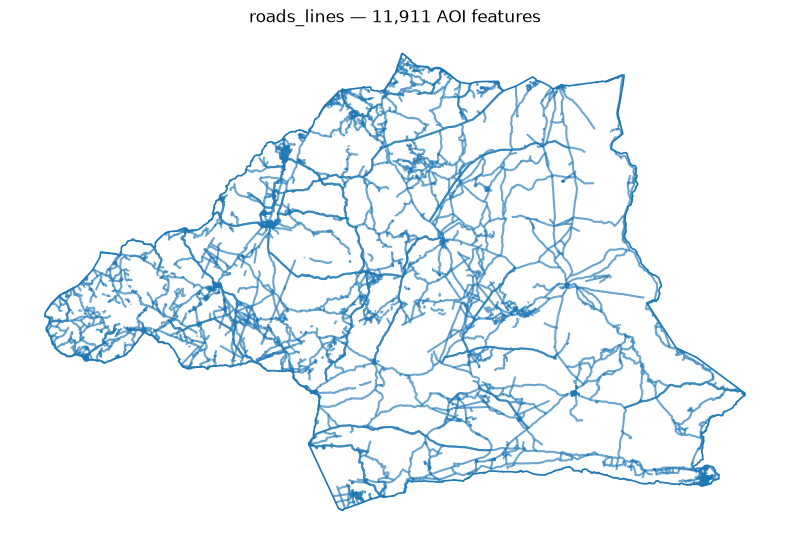

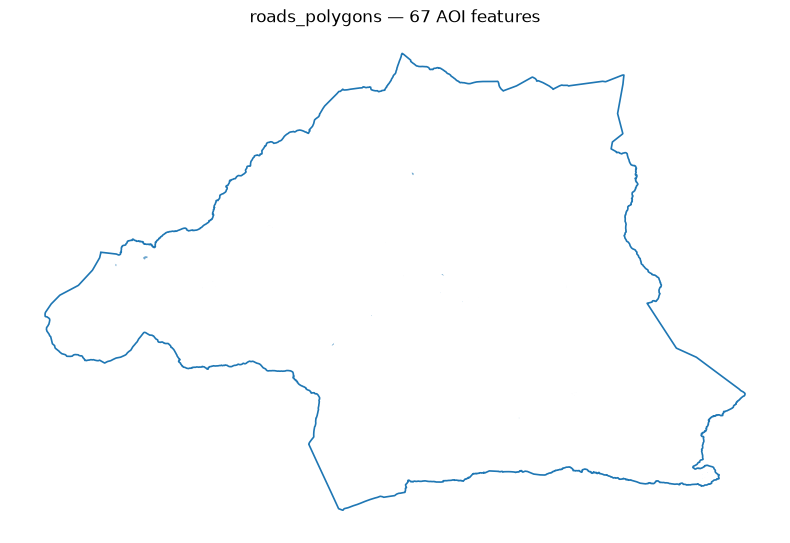

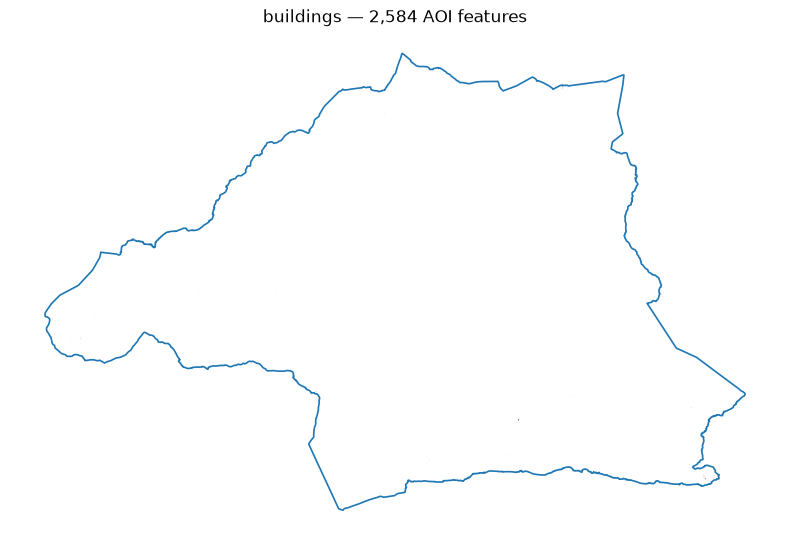

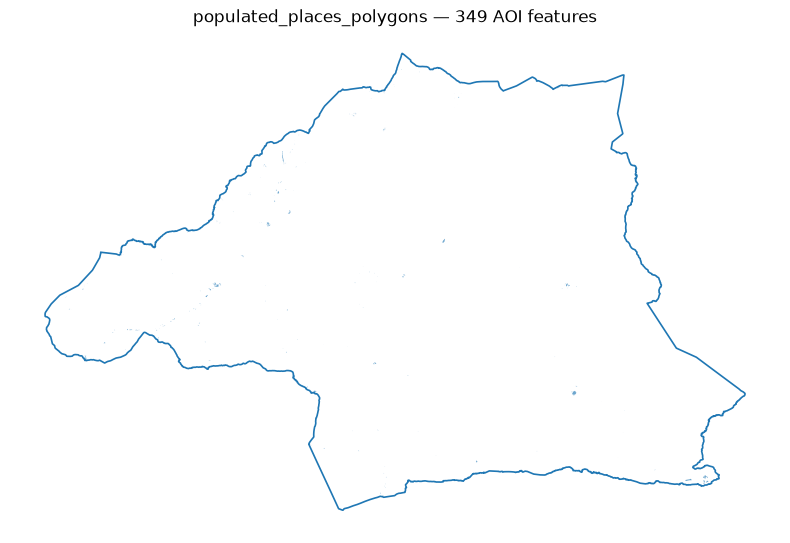

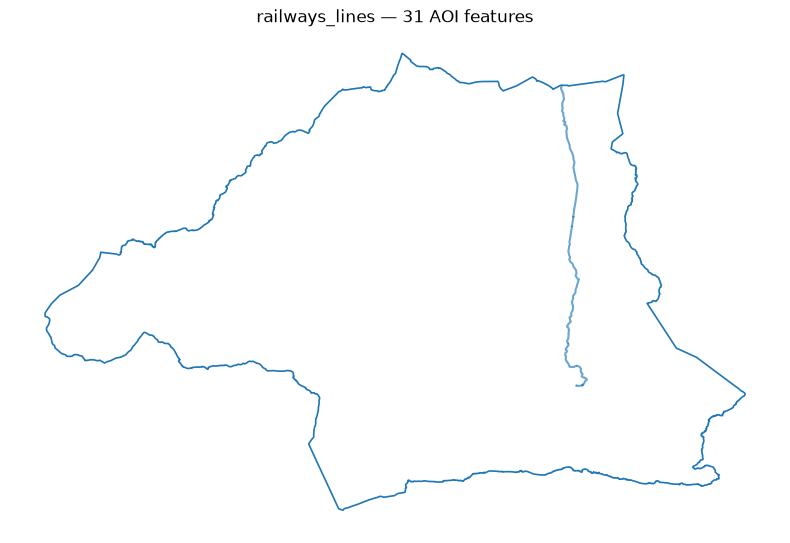

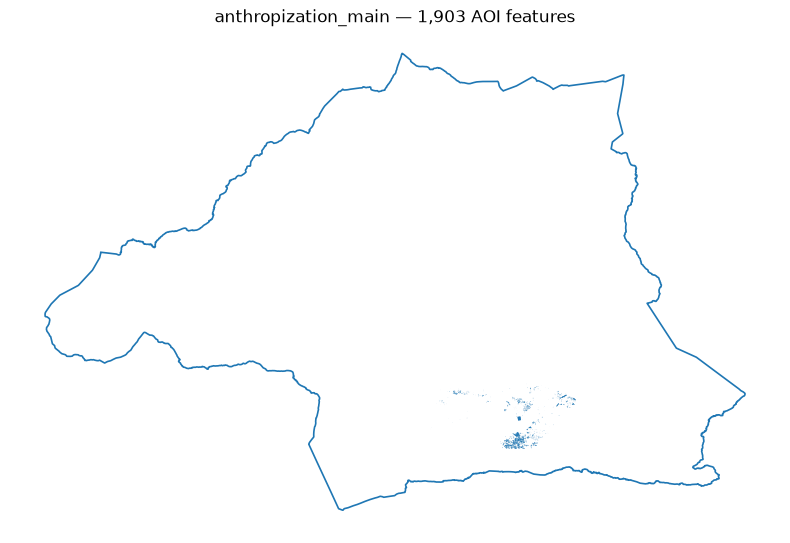

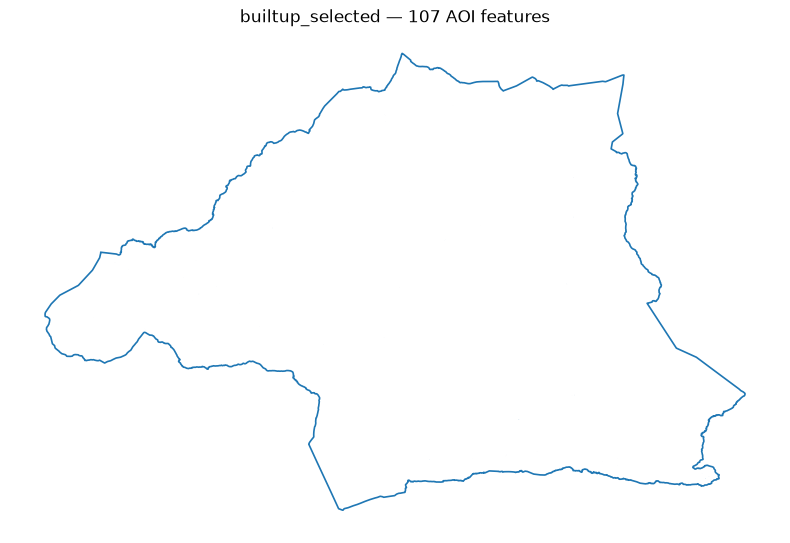

In [20]:
def quicklook(
    name: str,
    gdf: gpd.GeoDataFrame,
    aoi_boundary: gpd.GeoDataFrame,
    max_features: int = 50_000,
) -> None:
    if gdf.empty:
        print(name, "is empty in the AOI.")
        return

    plot_gdf = (
        gdf.sample(max_features, random_state=42)
        if len(gdf) > max_features
        else gdf
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    aoi_boundary.boundary.plot(ax=ax, linewidth=1.2)
    plot_gdf.plot(ax=ax, alpha=0.65)
    ax.set_title(f"{name} — {len(gdf):,} AOI features")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


# Change this list after reviewing the inventory.
QUICKLOOK_KEYS = [
    "roads_lines",
    "roads_polygons",
    "buildings",
    "populated_places_polygons",
    "railways_lines",
    "railways_polygons",
    "anthropization_main",
    "builtup_all_candidates",
    "builtup_selected",
]

for key in QUICKLOOK_KEYS:
    if key in aoi_layers:
        quicklook(key, aoi_layers[key], aoi)


## 9. Export cleaned exact-AOI and 5-km-context GeoPackages

The export preserves all cleaned attributes and adds provenance fields. Empty or missing layers are skipped.

The two products serve different purposes:

- `EM_HumanPressure_inputs_AOI_clean.gpkg`: visual review, feature summaries, and maps constrained to the study boundary;
- `EM_HumanPressure_inputs_context5km_clean.gpkg`: later distance and 5-km neighborhood calculations, followed by masking final rasters to the AOI.


In [23]:
def sanitize_for_gpkg(
    gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Convert uncommon Python/pandas objects into
    GeoPackage-compatible values before export.
    """

    x = gdf.copy()

    for column in x.columns:

        if column == "geometry":
            continue

        series = x[column]

        # -----------------------------------------
        # Categorical columns -> strings
        # -----------------------------------------
        if isinstance(
            series.dtype,
            pd.CategoricalDtype
        ):
            x[column] = (
                series
                .astype("string")
            )

        # -----------------------------------------
        # Object columns
        # -----------------------------------------
        elif pd.api.types.is_object_dtype(
            series.dtype
        ):

            complex_types = (
                list,
                tuple,
                set,
                dict,
                np.ndarray
            )

            has_complex = (
                series
                .dropna()
                .map(
                    lambda value:
                    isinstance(
                        value,
                        complex_types
                    )
                )
                .any()
            )

            if has_complex:

                x[column] = series.map(
                    lambda value:
                    json.dumps(
                        value,
                        default=str
                    )
                    if isinstance(
                        value,
                        complex_types
                    )
                    else value
                )

    return x

## 10. Review checklist before pressure-layer construction

Proceed to the temporal and raster workflow only after confirming the following:

1. The AOI and all sources use the expected locations and CRS.
2. `anthropization_main` has a defensible date/year field and its actual temporal range is known.
3. Anthropization categories have been separated into infrastructure, land transformation, observed activity, and any non-pressure records.
4. Road `highway` values have been reviewed and roads/tracks can be grouped without treating all lines equally.
5. Railway status/type fields have been reviewed; proposed or abandoned features are handled separately.
6. Building tags and obvious ruins/non-buildings have been reviewed, but the full source remains separate from training candidates.
7. Populated-place categories and coverage have been checked; add the HOTOSM populated-place point layer later if small settlements are missing.
8. Road/rail polygons have a clearly defined auxiliary role and are not double-counted with line layers.
9. Raw cultivation sources and derived training layers are recognized as duplicates/derivatives rather than independent evidence.
10. Exact AOI and 5-km context outputs have been retained separately.

After this audit, the next notebook should standardize categories and assign explicit temporal classes. Rasterization and annual index construction should come only after those decisions.


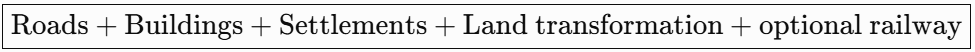

**cited from `EM_HumanPressure_01_PublicInputs_Finalize.ipynb`**

```Text
Summary of the datasets

The anthropization_main layer is not really a general human-activity dataset. It is overwhelmingly a cultivation/land-transformation inventory:
Cultivated: 1,836 / 1,903 = 96.5%
Uncultivated: 51
Restore Ecosystem Activity: 16

This is a temporally repeated inventory of cultivated/anthropized land, with a small number of uncultivated and restoration polygons.

The temporal pattern is:

Year	Cultivated	Restore	Uncultivated	Total
2015	284	6	2	292
2022	289	2	20	311
2023	458	2	19	479
2024	604	6	6	616
2025	201	0	4	205

Human footprint/
│
├── 00_input_audit/
│
├── 01_accessibility/
│   ├── roads
│   └── railway
│
├── 02_settlement/
│   ├── buildings
│   └── populated_places
│
├── 03_land_transformation/
│   ├── cultivation
│   ├── uncultivated_former_land
│   └── restoration
│
├── 04_annual_products/
│
├── 05_rsf_covariates/
│
└── 06_validation/


Human footprint/
└── 01_public_inputs/
    ├── EM_HumanPressure_public_inputs_AOI.gpkg
    ├── EM_HumanPressure_public_inputs_context5km.gpkg
    ├── EM_HumanPressure_final_dataset_decisions.csv
    ├── EM_HumanPressure_final_input_summary.csv
    └── rasters/
        ├── ghsl_built_2025_AOI.tif
        ├── ghsl_built_2025_context5km.tif
        ├── ghsl_population_2025_AOI.tif
        └── ghsl_population_2025_context5km.tif

## Cleaned Finnal Datasets
finalizes the public/local input datasets before deriving human-pressure covariates. It:

- prefers already clipped `*_EM` vectors when present;
- otherwise clips national vectors to the Eastern Morocco AOI plus a 5-km context buffer;
- uses line/point/polygon representations selectively to avoid double counting;
- clips GHSL rasters without resampling;
- exports cleaned AOI/context GeoPackages, raster clips, QC plots, and a final dataset summary.

In [48]:

from pathlib import Path
from typing import Any
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from rasterio.plot import show as rioshow
from shapely.geometry import mapping
import pyogrio
import fiona
from shapely import make_valid


In [49]:

PROJECT_ROOT = Path(
    r"C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data"
)

AOI_PATH = (
    PROJECT_ROOT
    / "Morocco two study areas"
    / "Eastern_Morocco_Working_Area.shp"
)

PUBLIC_ROOT = PROJECT_ROOT / "Habitat mapping" / "build-up"
WOF_ROOT = PUBLIC_ROOT / "whosonfirst-data-admin-ma-latest"

PREVIOUS_AUDIT_CONTEXT = (
    PROJECT_ROOT
    / "Human footprint"
    / "00_input_audit"
    / "EM_HumanPressure_inputs_context5km_clean.gpkg"
)

TARGET_CRS = "EPSG:32630"
CONTEXT_BUFFER_M = 5000

OUTPUT_ROOT = PROJECT_ROOT / "Human footprint" / "01_public_inputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

OUT_AOI_GPKG = OUTPUT_ROOT / "EM_HumanPressure_public_inputs_AOI.gpkg"
OUT_CONTEXT_GPKG = OUTPUT_ROOT / "EM_HumanPressure_public_inputs_context5km.gpkg"
OUT_DECISIONS_CSV = OUTPUT_ROOT / "EM_HumanPressure_final_dataset_decisions.csv"
OUT_SUMMARY_CSV = OUTPUT_ROOT / "EM_HumanPressure_final_input_summary.csv"
OUT_RASTER_DIR = OUTPUT_ROOT / "rasters"
OUT_RASTER_DIR.mkdir(parents=True, exist_ok=True)


In [60]:

VECTOR_SPECS = {
    "roads_osm": {
        "source_options": [PUBLIC_ROOT / "hotosm_mar_roads_lines_shp" / "hotosm_mar_roads_lines_shp.shp"],
        "layer": None,
        "family": "line",
        "status": "CORE",
        "role": "Primary road and track geometry",
    },  
    "roads_planet_attributes": {
        "source_options": [PUBLIC_ROOT / "heigit_MA_planet_roadsurface_lines.gpkg"],
        "layer": None,
        "family": "line",
        "status": "SUPPLEMENT",
        "role": "Planet-derived surface/width/passability attributes for arterial-road enrichment",
    },
    "buildings_osm": {
        "source_options": [PUBLIC_ROOT / "hotosm_mar_buildings_polygons_shp"],
        "layer": None,
        "family": "polygon",
        "status": "CORE",
        "role": "Recent building footprints",
    },
    "settlements_osm_points": {
        "source_options": [
            PUBLIC_ROOT / "hotosm_mar_populated_places_points_shp",
            PUBLIC_ROOT / "hotosm_mar_populated_places_points_gpkg.gpkg",
        ],
        "layer": None,
        "family": "point",
        "status": "CORE",
        "role": "Primary settlement/locality locations",
    },
    "settlements_wof_locality_points": {
        "source_options": [
            WOF_ROOT / "whosonfirst-data-admin-ma-locality-point.shp"
        ],
        "layer": None,
        "family": "point",
        "status": "SUPPLEMENT",
        "role": "Supplementary locality/gazetteer points",
    },
    "railways_osm": {
        "source_options": [PUBLIC_ROOT / "hotosm_mar_railways_lines_shp" / "hotosm_mar_railways_lines_shp.shp"],
        "layer": None,
        "family": "line",
        "status": "CANDIDATE",
        "role": "Railway-distance candidate",
    },
    "anthropization_local": {
        "source_options": [PREVIOUS_AUDIT_CONTEXT],
        "layer": "anthropization_main",
        "family": "polygon",
        "status": "CORE",
        "role": "Local cultivation / land-transformation reference",
    },
}

RASTER_SPECS = {
    "ghsl_built_2025": {
        "path": PUBLIC_ROOT / "ghs_built_s_e2025_r2023a_54009_100_v1_0_mar.tif",
        "status": "VALIDATION",
        "role": "Coarse built-up context / validation",
    },
    "ghsl_population_2025": {
        "path": PUBLIC_ROOT / "ghs_pop_e2025_r2023a_54009_100_v1_0_mar.tif",
        "status": "VALIDATION",
        "role": "Coarse population / settlement-intensity context",
    },
}

decision_table = pd.DataFrame([
    ["HOTOSM roads - lines", "CORE", "Use", "Primary road/track geometry"],
    ["HeiGIT Planet road surface/width/passability - lines", "SUPPLEMENT", "Use", "Attribute enrichment only; do not double-count roads"],
    ["HOTOSM roads - polygons", "EXCLUDE", "Do not use", "Redundant with road lines"],
    ["HOTOSM buildings - polygons", "CORE", "Use", "Building footprint, density and distance"],
    ["HOTOSM populated places - points", "CORE", "Use", "Preferred settlement representation"],
    ["HOTOSM populated places - polygons", "AUXILIARY", "Reference only", "Most place tags were null; avoid duplicate settlement pressure"],
    ["WOF locality - points", "SUPPLEMENT", "Use", "Gap filling / gazetteer; deduplicate against OSM later"],
    ["WOF locality - polygons", "EXCLUDE", "Do not use", "Locality boundary is not built-up footprint"],
    ["WOF neighbourhood/localadmin/campus - points", "EXCLUDE", "Not first model", "Administrative or intra-settlement detail"],
    ["WOF region/county/country - polygons", "EXCLUDE", "Do not use", "Administrative boundaries"],
    ["HOTOSM railways - lines", "CANDIDATE", "Use provisionally", "Railway-distance covariate"],
    ["HOTOSM railways - polygons", "EXCLUDE", "Do not use", "Prefer railway lines"],
    ["GHSL built-up 2025", "VALIDATION", "Use", "Independent coarse built-up benchmark"],
    ["GHSL population 2025", "VALIDATION", "Use", "Regional population/settlement intensity"],
    ["Reneco anthropization", "CORE", "Use", "Cultivation / land-transformation reference"],
    ["BuiltUp_Candidates_2025", "EXCLUDE", "Training only", "Derived from OSM buildings"],
    ["Cultivated training GeoPackage", "EXCLUDE", "Training only", "Derived from raw cultivation sources"],
], columns=["dataset", "final_status", "decision", "intended_role"])

decision_table.to_csv(OUT_DECISIONS_CSV, index=False)
display(decision_table)


,dataset,final_status,decision,intended_role
0,HOTOSM roads - lines,CORE,Use,Primary road/track geometry
1,HeiGIT Planet road surface/width/passability - lines,SUPPLEMENT,Use,Attribute enrichment only; do not double-count roads
2,HOTOSM roads - polygons,EXCLUDE,Do not use,Redundant with road lines
3,HOTOSM buildings - polygons,CORE,Use,"Building footprint, density and distance"
4,HOTOSM populated places - points,CORE,Use,Preferred settlement representation
5,HOTOSM populated places - polygons,AUXILIARY,Reference only,Most place tags were null; avoid duplicate settlement pressure
6,WOF locality - points,SUPPLEMENT,Use,Gap filling / gazetteer; deduplicate against OSM later
7,WOF locality - polygons,EXCLUDE,Do not use,Locality boundary is not built-up footprint
8,WOF neighbourhood/localadmin/campus - points,EXCLUDE,Not first model,Administrative or intra-settlement detail
9,WOF region/county/country - polygons,EXCLUDE,Do not use,Administrative boundaries


In [57]:

GEOM_TYPES = {
    "point": {"Point", "MultiPoint"},
    "line": {"LineString", "MultiLineString", "LinearRing"},
    "polygon": {"Polygon", "MultiPolygon"},
}

def list_vector_files(folder: Path):
    files = []
    if folder.exists():
        for pattern in ("*.shp", "*.gpkg", "*.geojson"):
            files.extend(folder.glob(pattern))
    return sorted(set(files))

def resolve_vector_path(options):
    for option in map(Path, options):
        if option.is_file():
            return option
        if option.is_dir():
            files = list_vector_files(option)
            em = [p for p in files if "_em" in p.stem.lower()]
            if len(em) == 1:
                return em[0]
            if len(files) == 1:
                return files[0]
            if len(em) > 1:
                raise ValueError(f"Multiple *_EM files in {option}: {em}")
            if len(files) > 1:
                raise ValueError(f"Multiple vector files in {option}: {files}")
    return None

def list_layers(path):
    if Path(path).suffix.lower() != ".gpkg":
        return []
    if pyogrio is not None:
        return [row[0] for row in pyogrio.list_layers(path)]
    if fiona is not None:
        return list(fiona.listlayers(path))
    return []

def resolve_layer(path, requested=None):
    if Path(path).suffix.lower() != ".gpkg":
        return None
    layers = list_layers(path)
    if requested:
        if requested not in layers:
            raise ValueError(f"{requested} not in {layers}")
        return requested
    if len(layers) == 1:
        return layers[0]
    if len(layers) > 1:
        raise ValueError(f"Multiple layers in {path}: {layers}")
    return None

def clean_geometry(gdf, family=None):
    x = gdf.copy()
    if x.crs is None:
        raise ValueError("Missing CRS")
    x = x.loc[x.geometry.notna() & ~x.geometry.is_empty].copy()
    bad = ~x.geometry.is_valid
    if bad.any():
        x.loc[bad, "geometry"] = x.loc[bad, "geometry"].apply(make_valid)
    x = x.loc[x.geometry.notna() & ~x.geometry.is_empty].copy()
    x = x.explode(index_parts=False, ignore_index=True)
    if family:
        x = x.loc[x.geometry.geom_type.isin(GEOM_TYPES[family])].copy()
    if family == "polygon":
        x = x.loc[x.geometry.apply(lambda g: g.area > 0)].copy()
    if family == "line":
        x = x.loc[x.geometry.apply(lambda g: g.length > 0)].copy()
    return x.reset_index(drop=True)

def sanitize_for_gpkg(gdf):
    x = gdf.copy()
    complex_types = (list, tuple, set, dict, np.ndarray)
    for c in x.columns:
        if c == "geometry":
            continue
        s = x[c]
        if isinstance(s.dtype, pd.CategoricalDtype):
            x[c] = s.astype("string")
        elif pd.api.types.is_object_dtype(s.dtype):
            if s.dropna().map(lambda v: isinstance(v, complex_types)).any():
                x[c] = s.map(
                    lambda v: json.dumps(v, default=str)
                    if isinstance(v, complex_types) else v
                )
    return x


In [58]:

# AOI
aoi_raw = gpd.read_file(
    AOI_PATH,
    engine="pyogrio" if pyogrio is not None else None,
)
aoi_clean = clean_geometry(aoi_raw, "polygon").to_crs(TARGET_CRS)

union_geom = (
    aoi_clean.geometry.union_all()
    if hasattr(aoi_clean.geometry, "union_all")
    else aoi_clean.geometry.unary_union
)

aoi = gpd.GeoDataFrame(
    {"aoi_name": ["Eastern_Morocco_Working_Area"]},
    geometry=[union_geom],
    crs=TARGET_CRS,
)

aoi_context = aoi.copy()
aoi_context["geometry"] = aoi_context.geometry.buffer(CONTEXT_BUFFER_M)

print("AOI CRS:", aoi.crs)
print("AOI area km2:", round(aoi.geometry.area.iloc[0] / 1e6, 2))


AOI CRS: EPSG:32630
AOI area km2: 50203.94


In [61]:

def read_vector_window(path, layer, boundary):
    kwargs = {}
    if layer is not None:
        kwargs["layer"] = layer
    if pyogrio is not None:
        kwargs["engine"] = "pyogrio"

    head = gpd.read_file(path, rows=1, **kwargs)
    boundary_src = boundary.to_crs(head.crs)
    bbox = tuple(boundary_src.total_bounds)
    return gpd.read_file(path, bbox=bbox, **kwargs)

def load_clip_one(key, spec):
    path = resolve_vector_path(spec["source_options"])
    if path is None:
        raise FileNotFoundError(f"No source found for {key}")
    layer = resolve_layer(path, spec.get("layer"))

    raw = read_vector_window(path, layer, aoi_context)
    clean = clean_geometry(raw, spec["family"]).to_crs(TARGET_CRS)

    context = gpd.clip(clean, aoi_context).reset_index(drop=True)
    exact = gpd.clip(context, aoi).reset_index(drop=True)

    if key == "buildings_osm" and "building" in exact.columns:
        exact["building"] = exact["building"].astype("string").str.lower().str.strip()
        exact = exact.loc[exact["building"] != "ruins"].copy()
        context["building"] = context["building"].astype("string").str.lower().str.strip()
        context = context.loc[context["building"] != "ruins"].copy()

    for gdf in (exact, context):
        gdf["_dataset"] = key
        gdf["_src_file"] = str(path)
        gdf["_src_layer"] = layer

    return exact, context, {
        "dataset": key,
        "final_status": spec["status"],
        "role": spec["role"],
        "source": str(path),
        "source_layer": layer,
        "preferred_EM_source": "_em" in path.stem.lower(),
        "geometry_family": spec["family"],
        "features_aoi": len(exact),
        "features_context5km": len(context),
    }

aoi_layers = {}
context_layers = {}
summary = []

for key, spec in VECTOR_SPECS.items():
    exact, context, info = load_clip_one(key, spec)
    aoi_layers[key] = exact
    context_layers[key] = context
    summary.append(info)
    print(key, "AOI:", len(exact), "| context:", len(context), "|", info["source"])

vector_summary = pd.DataFrame(summary)
display(vector_summary)


roads_osm AOI: 11170 | context: 13820 | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_lines_shp\hotosm_mar_roads_lines_shp.shp
roads_planet_attributes AOI: 690 | context: 815 | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\heigit_MA_planet_roadsurface_lines.gpkg
buildings_osm AOI: 2570 | context: 2570 | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp\hotosm_mar_buildings_polygons_EM.shp
settlements_osm_points AOI: 169 | context: 214 | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_points_shp\hotosm_mar_populated_places_points_shp.shp
settlements_wof_locality_points AOI: 171 | context: 247 | C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\whosonfirst-data-admin-ma-latest\whosonfirst-data-admin

,dataset,final_status,role,source,source_layer,preferred_EM_source,geometry_family,features_aoi,features_context5km
0,roads_osm,CORE,Primary road and track geometry,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_lines_shp\hotosm_mar_roads_lines_shp.shp,None,False,line,11170,13820
1,roads_planet_attributes,SUPPLEMENT,Planet-derived surface/width/passability attributes for arterial-road enrichment,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\heigit_MA_planet_roadsurface_lines.gpkg,heigit_MA_planet_roadsurface_lines,False,line,690,815
2,buildings_osm,CORE,Recent building footprints,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp\hotosm_mar_buildings_polygons_E...,None,True,polygon,2570,2570
3,settlements_osm_points,CORE,Primary settlement/locality locations,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_points_shp\hotosm_mar_populated_place...,None,False,point,169,214
4,settlements_wof_locality_points,SUPPLEMENT,Supplementary locality/gazetteer points,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\whosonfirst-data-admin-ma-latest\whosonfirst-data-admin-ma-locali...,None,False,point,171,247
5,railways_osm,CANDIDATE,Railway-distance candidate,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_lines_shp\hotosm_mar_railways_lines_shp.shp,None,False,line,31,33
6,anthropization_local,CORE,Local cultivation / land-transformation reference,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\00_input_audit\EM_HumanPressure_inputs_context5km_clean.gpkg,anthropization_main,False,polygon,1903,1903


In [62]:

def export_gpkg(path, layers, boundary):
    if path.exists():
        path.unlink()
    engine = "pyogrio" if pyogrio is not None else None
    boundary.to_file(path, layer="study_aoi", driver="GPKG", engine=engine)
    written = ["study_aoi"]
    for key, gdf in layers.items():
        if gdf is None or gdf.empty:
            continue
        sanitize_for_gpkg(gdf).to_file(
            path, layer=key, driver="GPKG", engine=engine
        )
        written.append(key)
    print("Saved:", path)
    print("Layers:", written)

export_gpkg(OUT_AOI_GPKG, aoi_layers, aoi)
export_gpkg(OUT_CONTEXT_GPKG, context_layers, aoi_context)


Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_public_inputs_AOI.gpkg
Layers: ['study_aoi', 'roads_osm', 'roads_planet_attributes', 'buildings_osm', 'settlements_osm_points', 'settlements_wof_locality_points', 'railways_osm', 'anthropization_local']
Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_public_inputs_context5km.gpkg
Layers: ['study_aoi', 'roads_osm', 'roads_planet_attributes', 'buildings_osm', 'settlements_osm_points', 'settlements_wof_locality_points', 'railways_osm', 'anthropization_local']


In [64]:

def clip_raster(src_path, boundary, out_path):
    with rasterio.open(src_path) as src:
        boundary_src = boundary.to_crs(src.crs)
        geoms = [mapping(g) for g in boundary_src.geometry]
        data, transform = mask(
            src, geoms, crop=True, filled=True, nodata=src.nodata
        )
        profile = src.profile.copy()
        profile.update(
            height=data.shape[1],
            width=data.shape[2],
            transform=transform,
            compress="deflate",
        )
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data)

        arr = data[0]
        valid = arr[np.isfinite(arr)]
        if src.nodata is not None:
            valid = valid[valid != src.nodata]

        return {
            "source_crs": str(src.crs),
            "valid_pixels": int(valid.size),
            "min": float(valid.min()) if valid.size else np.nan,
            "mean": float(valid.mean()) if valid.size else np.nan,
            "max": float(valid.max()) if valid.size else np.nan,
        }

raster_rows = []

for key, spec in RASTER_SPECS.items():
    src_path = spec["path"]
    out_aoi = OUT_RASTER_DIR / f"{key}_AOI.tif"
    out_context = OUT_RASTER_DIR / f"{key}_context5km.tif"

    stat_aoi = clip_raster(src_path, aoi, out_aoi)
    clip_raster(src_path, aoi_context, out_context)

    raster_rows.append({
        "dataset": key,
        "final_status": spec["status"],
        "role": spec["role"],
        "source": str(src_path),
        "geometry_family": "raster",
        "features_aoi": np.nan,
        "features_context5km": np.nan,
        "preferred_EM_source": False,
        **stat_aoi,
    })

raster_summary = pd.DataFrame(raster_rows)
display(raster_summary)


,dataset,final_status,role,source,geometry_family,features_aoi,features_context5km,preferred_EM_source,source_crs,valid_pixels,min,mean,max
0,ghsl_built_2025,VALIDATION,Coarse built-up context / validation,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\ghs_built_s_e2025_r2023a_54009_100_v1_0_mar.tif,raster,NaN,NaN,False,ESRI:54009,5003044,0.0,1.382307,6885.000000
1,ghsl_population_2025,VALIDATION,Coarse population / settlement-intensity context,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\ghs_pop_e2025_r2023a_54009_100_v1_0_mar.tif,raster,NaN,NaN,False,ESRI:54009,5003042,0.0,0.073822,2488.328613


In [65]:

# Combined runtime summary
summary_cols = [
    "dataset", "final_status", "role", "geometry_family",
    "features_aoi", "features_context5km", "preferred_EM_source", "source"
]
final_input_summary = pd.concat(
    [
        vector_summary.reindex(columns=summary_cols),
        raster_summary.reindex(columns=summary_cols),
    ],
    ignore_index=True,
)
final_input_summary.to_csv(OUT_SUMMARY_CSV, index=False)
display(final_input_summary)
print("Saved:", OUT_SUMMARY_CSV)


,dataset,final_status,role,geometry_family,features_aoi,features_context5km,preferred_EM_source,source
0,roads_osm,CORE,Primary road and track geometry,line,11170.0,13820.0,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_roads_lines_shp\hotosm_mar_roads_lines_shp.shp
1,roads_planet_attributes,SUPPLEMENT,Planet-derived surface/width/passability attributes for arterial-road enrichment,line,690.0,815.0,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\heigit_MA_planet_roadsurface_lines.gpkg
2,buildings_osm,CORE,Recent building footprints,polygon,2570.0,2570.0,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp\hotosm_mar_buildings_polygons_E...
3,settlements_osm_points,CORE,Primary settlement/locality locations,point,169.0,214.0,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_points_shp\hotosm_mar_populated_place...
4,settlements_wof_locality_points,SUPPLEMENT,Supplementary locality/gazetteer points,point,171.0,247.0,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\whosonfirst-data-admin-ma-latest\whosonfirst-data-admin-ma-locali...
5,railways_osm,CANDIDATE,Railway-distance candidate,line,31.0,33.0,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_lines_shp\hotosm_mar_railways_lines_shp.shp
6,anthropization_local,CORE,Local cultivation / land-transformation reference,polygon,1903.0,1903.0,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\00_input_audit\EM_HumanPressure_inputs_context5km_clean.gpkg
7,ghsl_built_2025,VALIDATION,Coarse built-up context / validation,raster,NaN,NaN,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\ghs_built_s_e2025_r2023a_54009_100_v1_0_mar.tif
8,ghsl_population_2025,VALIDATION,Coarse population / settlement-intensity context,raster,NaN,NaN,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\ghs_pop_e2025_r2023a_54009_100_v1_0_mar.tif


Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_final_input_summary.csv



## Representation choices

- **Roads:** use lines; exclude road polygons from pressure calculations.
- **Railways:** use lines; exclude railway polygons.
- **HOTOSM populated places:** use points for settlement proximity/hierarchy; polygons remain auxiliary only.
- **WOF:** use locality points as the useful supplementary settlement source; exclude locality/admin polygons and other administrative point types from the first model.
- **Buildings:** use polygons.
- **GHSL:** retain at its native raster resolution for context/validation at this stage; do not resample to 30 m here.


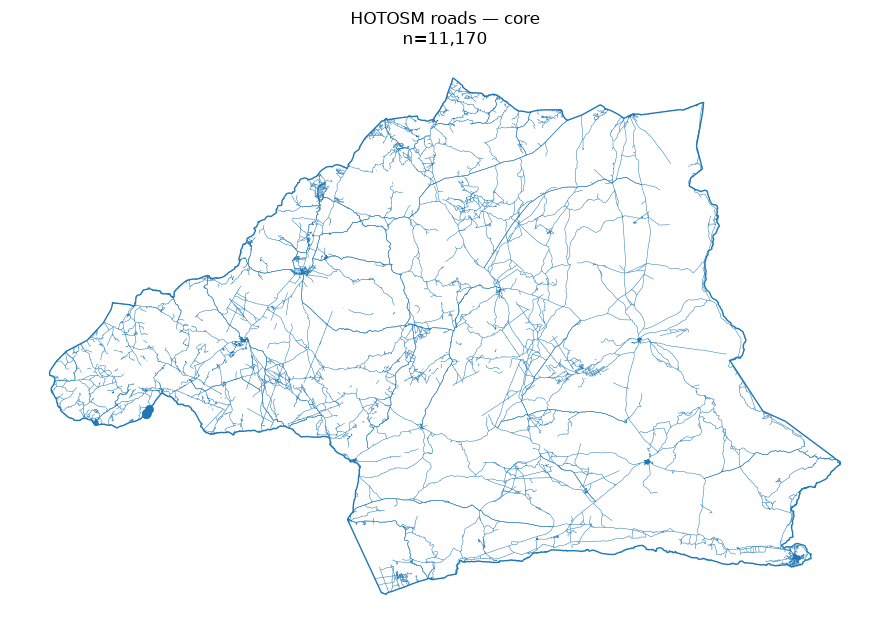

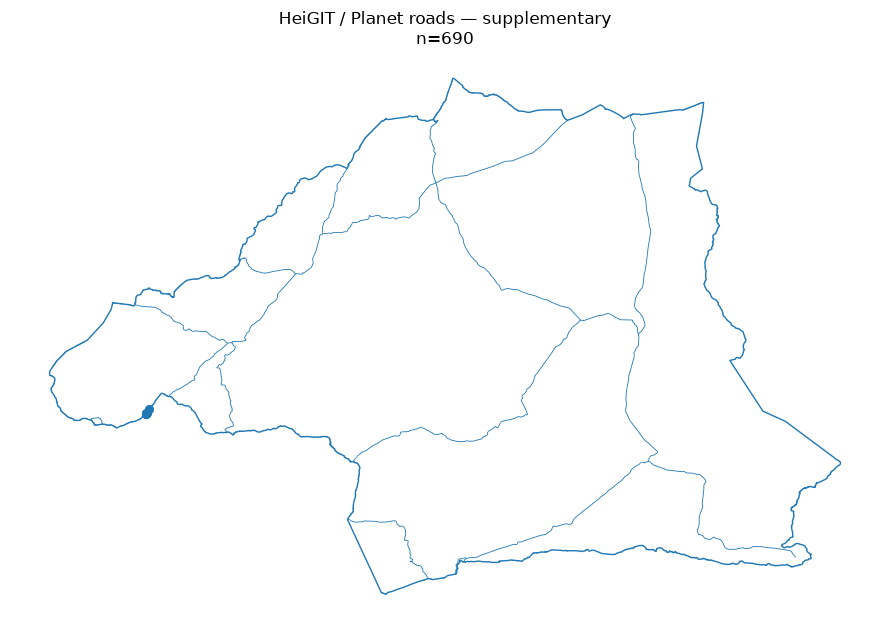

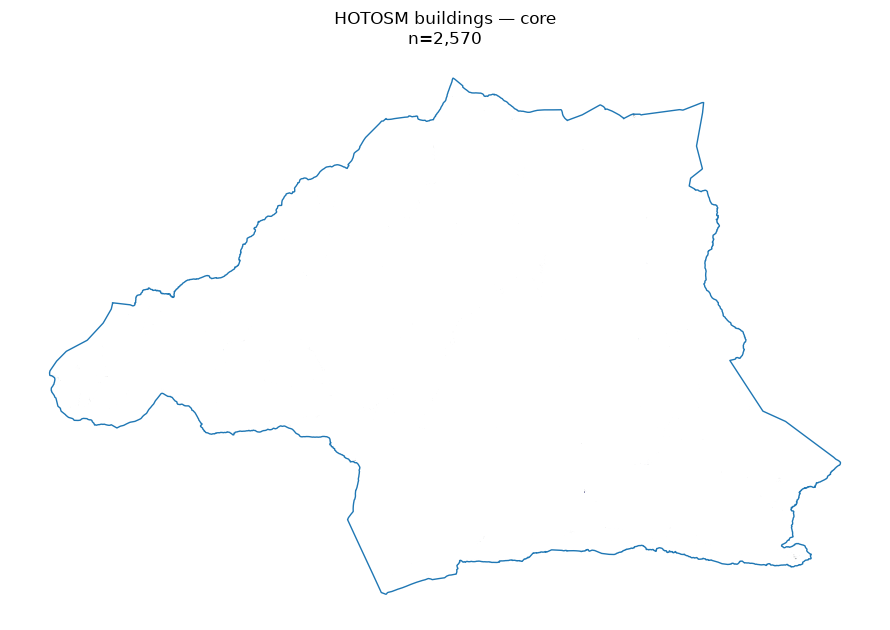

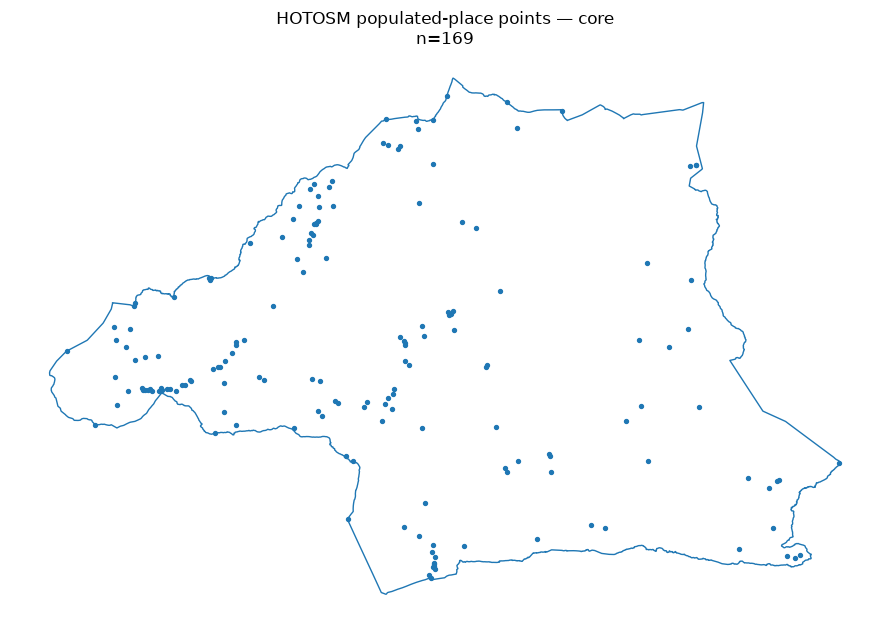

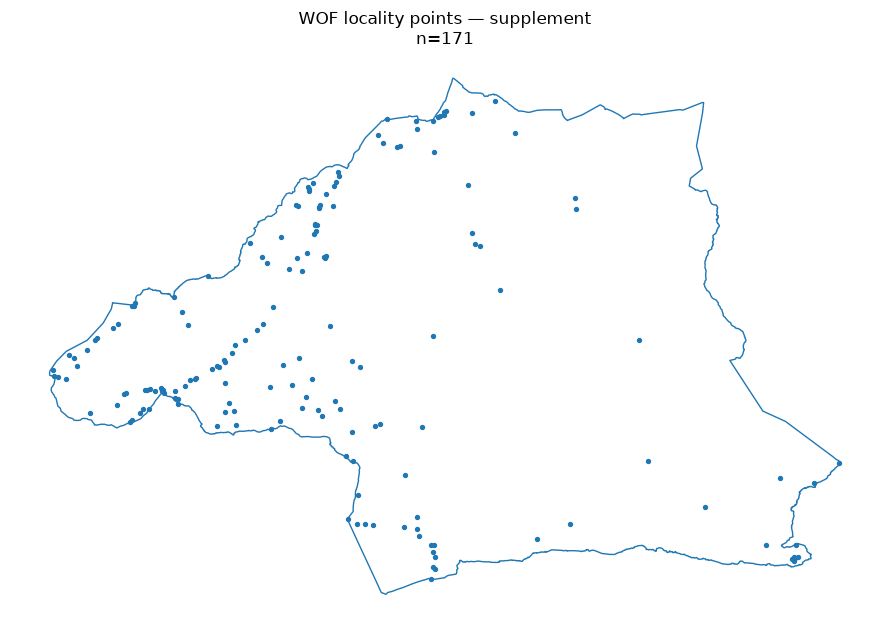

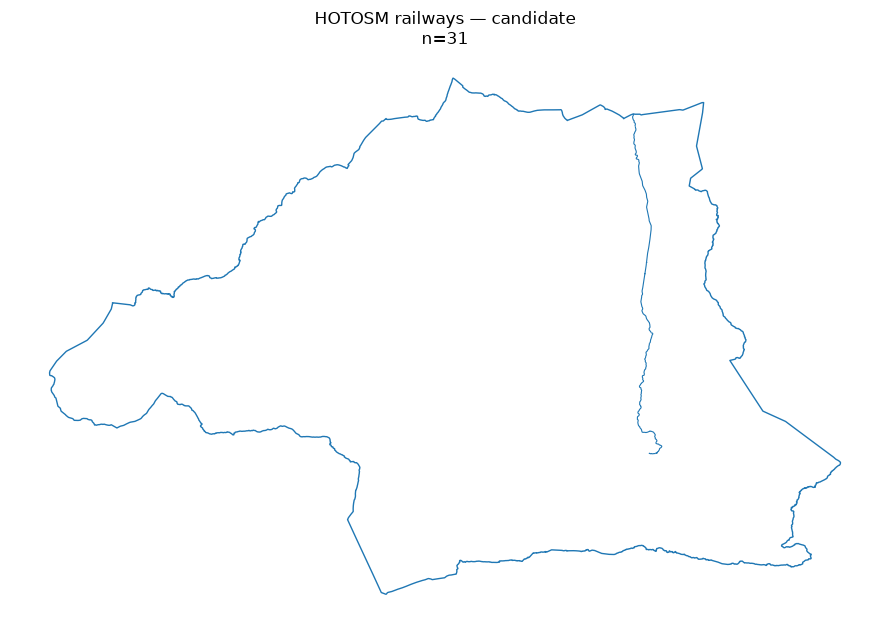

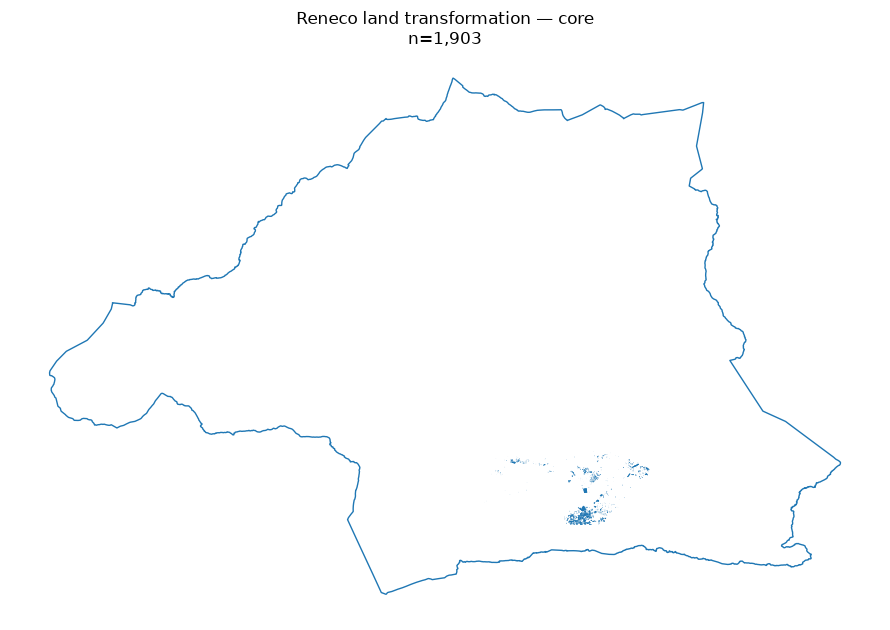

In [67]:

def plot_vector(gdf, title, markersize=5, linewidth=0.5):
    fig, ax = plt.subplots(figsize=(9, 9))
    aoi.boundary.plot(ax=ax, linewidth=1)
    types = set(gdf.geometry.geom_type)
    if types.issubset({"Point", "MultiPoint"}):
        gdf.plot(ax=ax, markersize=markersize)
    else:
        gdf.plot(ax=ax, linewidth=linewidth)
    ax.set_title(f"{title}\nn={len(gdf):,}")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

plot_vector(aoi_layers["roads_osm"], "HOTOSM roads — core", linewidth=0.35)
plot_vector(aoi_layers["roads_planet_attributes"], "HeiGIT / Planet roads — supplementary", linewidth=0.6)
plot_vector(aoi_layers["buildings_osm"], "HOTOSM buildings — core", linewidth=0.3)
plot_vector(aoi_layers["settlements_osm_points"], "HOTOSM populated-place points — core", markersize=8)
plot_vector(aoi_layers["settlements_wof_locality_points"], "WOF locality points — supplement", markersize=8)
plot_vector(aoi_layers["railways_osm"], "HOTOSM railways — candidate", linewidth=0.8)
plot_vector(aoi_layers["anthropization_local"], "Reneco land transformation — core", linewidth=0.3)


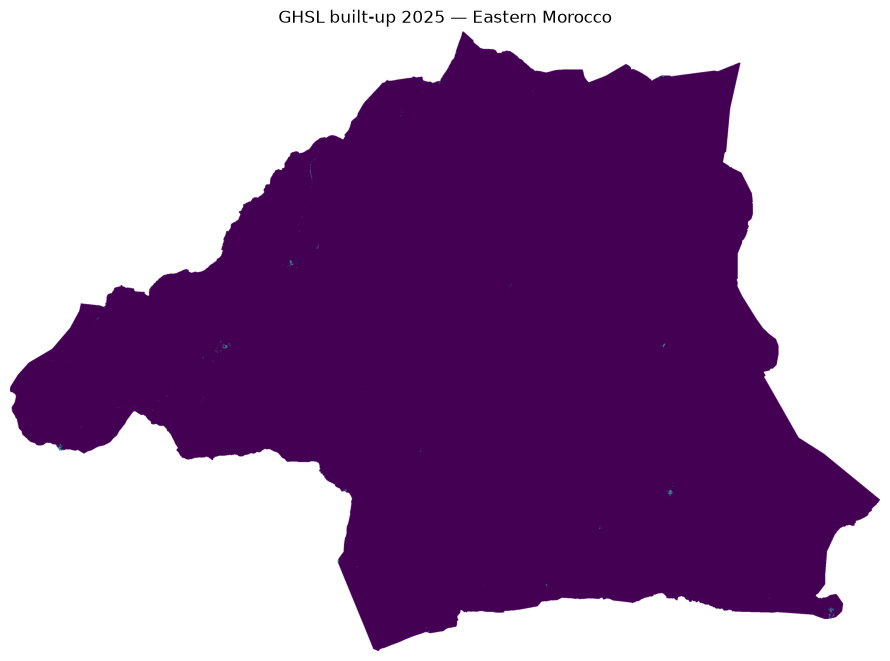

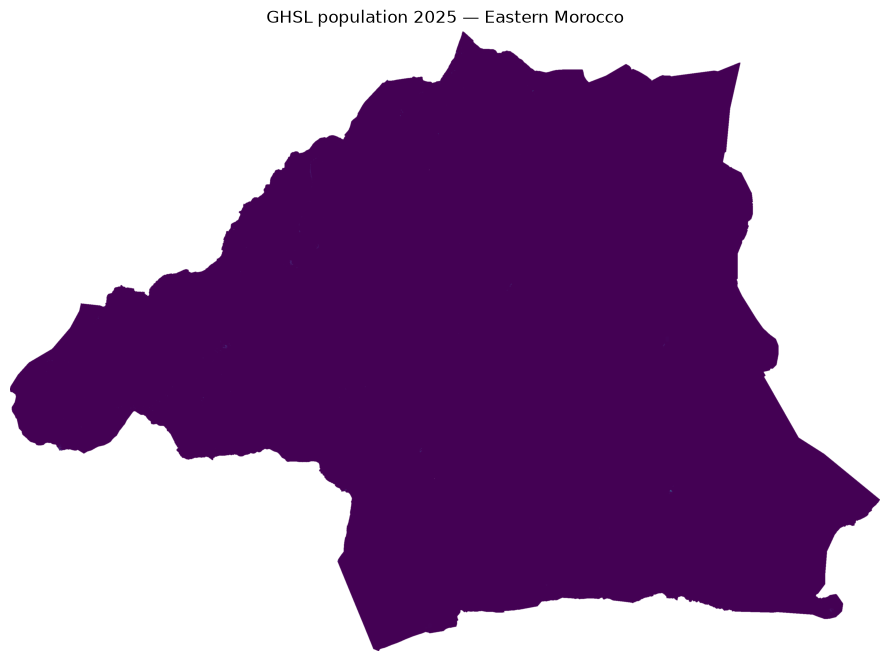

In [68]:

def plot_raster(path, title):
    with rasterio.open(path) as src:
        fig, ax = plt.subplots(figsize=(9, 9))
        rioshow(src, ax=ax)
        ax.set_title(title)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()

plot_raster(
    OUT_RASTER_DIR / "ghsl_built_2025_AOI.tif",
    "GHSL built-up 2025 — Eastern Morocco",
)
plot_raster(
    OUT_RASTER_DIR / "ghsl_population_2025_AOI.tif",
    "GHSL population 2025 — Eastern Morocco",
)


In [69]:

print("FINAL INCLUDED / RETAINED INPUTS")
display(
    decision_table[
        decision_table["final_status"].isin(
            ["CORE", "SUPPLEMENT", "CANDIDATE", "VALIDATION"]
        )
    ]
)

print("\nOutputs:")
print(OUT_AOI_GPKG)
print(OUT_CONTEXT_GPKG)
print(OUT_DECISIONS_CSV)
print(OUT_SUMMARY_CSV)
print(OUT_RASTER_DIR)


FINAL INCLUDED / RETAINED INPUTS


,dataset,final_status,decision,intended_role
0,HOTOSM roads - lines,CORE,Use,Primary road/track geometry
1,HeiGIT Planet road surface/width/passability - lines,SUPPLEMENT,Use,Attribute enrichment only; do not double-count roads
3,HOTOSM buildings - polygons,CORE,Use,"Building footprint, density and distance"
4,HOTOSM populated places - points,CORE,Use,Preferred settlement representation
6,WOF locality - points,SUPPLEMENT,Use,Gap filling / gazetteer; deduplicate against OSM later
10,HOTOSM railways - lines,CANDIDATE,Use provisionally,Railway-distance covariate
12,GHSL built-up 2025,VALIDATION,Use,Independent coarse built-up benchmark
13,GHSL population 2025,VALIDATION,Use,Regional population/settlement intensity
14,Reneco anthropization,CORE,Use,Cultivation / land-transformation reference



Outputs:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_public_inputs_AOI.gpkg
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_public_inputs_context5km.gpkg
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_final_dataset_decisions.csv
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\EM_HumanPressure_final_input_summary.csv
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Human footprint\01_public_inputs\rasters


#### Review the datasets

In [24]:
# ============================================================
# REVIEW THE AUDIT OUTPUTS
# ============================================================

inventory = pd.read_csv(
    OUT_INVENTORY_CSV
)

schema = pd.read_csv(
    OUT_SCHEMA_CSV
)

values = pd.read_csv(
    OUT_VALUES_CSV
)

overlap = pd.read_csv(
    OUT_OVERLAP_CSV
)

decisions = pd.read_csv(
    OUT_DECISIONS_CSV
)


print("=" * 70)
print("INPUT INVENTORY")
print("=" * 70)

display(
    inventory
)


print("\n" + "=" * 70)
print("DATASET DECISIONS")
print("=" * 70)

display(
    decisions
)


print("\n" + "=" * 70)
print("OVERLAP REVIEW")
print("=" * 70)

display(
    overlap
)

INPUT INVENTORY


,dataset,status,required,resolved_path,source_layer,source_crs,target_crs,source_feature_count_metadata,features_read_bbox,features_after_geometry_qc,features_context5km,features_aoi,null_geometry_removed,empty_geometry_removed,invalid_geometry_before,invalid_geometry_after,unexpected_geometry_removed,zero_measure_removed,geometry_types_aoi,n_attribute_fields,id_field,duplicate_id_features,duplicate_id_values,duplicate_geometry_features,duplicate_geometry_values,total_area_km2,median_area_m2,total_length_km,median_length_m
0,albaten_farms_2024_raw,raw_land_transformation,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Al_Baten_occupation_Farms_202...,NaN,EPSG:4326,EPSG:32630,153,153,153,153,153,0,0,0,0,0,0,Polygon:153,10,NaN,0,0,0,0,13.978636,32514.443170,NaN,NaN
1,anthropization_main,primary_temporal,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Anthropization_2015_2025\Anthropization_2015_2025.shp,NaN,EPSG:32630,EPSG:32630,1901,1901,1903,1903,1903,0,0,0,0,0,0,Polygon:1903,10,NaN,0,0,665,315,155.651759,33118.187309,NaN,NaN
2,bouarfa_anthropized_2024_raw,raw_land_transformation,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Bouarfa_anthropized_land_1_20...,NaN,EPSG:32630,EPSG:32630,606,606,606,606,606,0,0,0,0,0,0,Polygon:606,11,NaN,0,0,0,0,43.600643,33383.264167,NaN,NaN
3,buildings,primary_recent_snapshot,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_buildings_polygons_shp\hotosm_mar_buildings_polygons_s...,NaN,EPSG:4326,EPSG:32630,1492048,13963,13965,4889,2584,0,0,0,0,0,0,Polygon:2584,19,osm_id,0,0,0,0,0.655687,131.911209,NaN,NaN
4,builtup_selected,derived_training_subset,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\Eastern_Morocco_BuiltUp_Candidates_2025.gpkg,builtup_selected,EPSG:32630,EPSG:32630,107,107,107,107,107,0,0,0,0,0,0,Polygon:107,26,NaN,0,0,0,0,0.483994,2717.337335,NaN,NaN
5,cultivated_albaten_2024_derived,derived_training,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Tr...,albaten_farms_2024,EPSG:32630,EPSG:32630,153,153,153,153,153,0,0,0,0,0,0,Polygon:153,23,NaN,0,0,0,0,13.978636,32514.443170,NaN,NaN
6,cultivated_bouarfa_2024_derived,derived_training,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Tr...,bouarfa_cultivated_2024,EPSG:32630,EPSG:32630,606,606,606,606,606,0,0,0,0,0,0,Polygon:606,22,NaN,0,0,0,0,43.600643,33383.264167,NaN,NaN
7,cultivated_combined_2024_derived,derived_training_combined,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Reneco\GIS Data\Extract data Yuwen\Shapefiles\anthropisation\Eastern_Morocco_Cultivated_Tr...,cultivated_combined,EPSG:32630,EPSG:32630,759,759,759,759,759,0,0,0,0,0,0,Polygon:759,25,NaN,0,0,0,0,57.579279,32975.733746,NaN,NaN
8,populated_places_polygons,primary_recent_snapshot,True,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_populated_places_polygons_shp\hotosm_mar_populated_pla...,NaN,EPSG:4326,EPSG:32630,37420,1218,1218,461,349,0,0,0,0,0,0,Polygon:349,15,osm_id,10,4,0,0,39.059291,25282.218054,NaN,NaN
9,railways_lines,primary_if_present,False,C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\Habitat mapping\build-up\hotosm_mar_railways_lines_shp\hotosm_mar_railways_lines_shp.shp,NaN,EPSG:4326,EPSG:32630,3266,225,225,33,31,0,0,0,0,0,0,LineString:31,17,osm_id,0,0,0,0,NaN,NaN,190.611036,466.083915



DATASET DECISIONS


,key,status,intended_use,caution
0,anthropization_main,primary_temporal,Temporal field evidence; retain subtypes and dates separately.,Survey effort and temporal meaning must be inspected before annualization.
1,roads_lines,primary,"Road/track distance, class-specific accessibility, and line density.",Current OSM snapshot; mapping date is not construction date.
2,roads_polygons,auxiliary,"Road-surface areas, plazas, parking, or special transport polygons after review.",May spatially duplicate road lines; do not add both representations as separate pressure counts.
3,buildings,primary_recent_snapshot,"Recent building footprint, density, clustering, and settlement proximity.",No annual construction dates; incomplete OSM coverage is possible.
4,populated_places_polygons,primary_recent_snapshot,"Settlement extent, type, and distance to mapped populated places.",Small places mapped only as points will be absent unless the point layer is added later.
5,railways_lines,primary_if_present,Distance to active or mapped railway corridors.,"Inspect railway type/status; abandoned, proposed, and service lines should not be treated equally."
6,railways_polygons,auxiliary,"Stations, yards, platforms, or railway land after attribute review.",May overlap railway lines; avoid double weighting.
7,builtup_all_candidates,derived_training,Audit/reference for the habitat-classification candidate workflow.,Derived from buildings; exclude as an independent HPI input.
8,builtup_selected,derived_training_subset,Selected habitat-training examples and visual validation only.,Spatially sampled subset; never use as building-pressure coverage.
9,albaten_farms_2024_raw,raw_land_transformation,Raw 2024 cultivated/occupation evidence for Al Baten.,May be duplicated in the cultivated training GeoPackage.



OVERLAP REVIEW


,check,metric,value
0,roads_polygons_to_roads_lines_nearest,n_source_features,67.000000
1,roads_polygons_to_roads_lines_nearest,median_distance_m,0.000000
2,roads_polygons_to_roads_lines_nearest,p95_distance_m,4.744311
3,roads_polygons_to_roads_lines_nearest,percent_within_0m,91.044776
4,roads_polygons_to_roads_lines_nearest,percent_within_5m,94.029851
5,roads_polygons_to_roads_lines_nearest,percent_within_10m,97.014925
6,roads_polygons_to_roads_lines_nearest,percent_within_25m,97.014925
7,roads_polygons_to_roads_lines_nearest,percent_within_50m,97.014925
8,buildings_within_builtup_selected,n_candidate_features,107.000000
9,buildings_within_builtup_selected,percent_candidates_intersecting_source,100.000000


In [26]:
# ============================================================
# CREATE CONVENIENT VARIABLES FROM AUDITED LAYERS
# ============================================================

roads_lines = aoi_layers["roads_lines"]
roads_polygons = aoi_layers["roads_polygons"]

buildings = aoi_layers["buildings"]

populated_places_polygons = (
    aoi_layers["populated_places_polygons"]
)

railways_lines = aoi_layers["railways_lines"]

anthropization_main = (
    aoi_layers["anthropization_main"]
)

builtup_selected = (
    aoi_layers["builtup_selected"]
)

print("Datasets ready:")
print("roads_lines:", len(roads_lines))
print("roads_polygons:", len(roads_polygons))
print("buildings:", len(buildings))
print(
    "populated_places_polygons:",
    len(populated_places_polygons)
)
print("railways_lines:", len(railways_lines))
print(
    "anthropization_main:",
    len(anthropization_main)
)

Datasets ready:
roads_lines: 11911
roads_polygons: 67
buildings: 2584
populated_places_polygons: 349
railways_lines: 31
anthropization_main: 1903


In [27]:
roads_lines.columns.tolist()
roads_lines["highway"].value_counts(
    dropna=False
)

highway
track             4757
residential       2774
service            833
primary            817
path               811
tertiary           657
unclassified       631
secondary          415
living_street       73
footway             72
construction        41
primary_link        16
secondary_link       6
proposed             3
pedestrian           2
tertiary_link        2
steps                1
Name: count, dtype: int64

In [28]:
# ============================================================
# INSPECT KEY ATTRIBUTES
# ============================================================

def inspect_column(
    gdf,
    column,
    n=30
):
    if column not in gdf.columns:
        print(
            f"'{column}' not found."
        )
        print(
            "Available columns:"
        )
        print(
            gdf.columns.tolist()
        )
        return

    display(
        gdf[column]
        .value_counts(
            dropna=False
        )
        .head(n)
        .to_frame("n")
    )

In [29]:
print("ROADS COLUMNS:")
print(
    roads_lines.columns.tolist()
)

for col in [
    "highway",
    "surface",
    "tracktype",
    "service",
    "smoothness",
]:
    print(
        f"\n--- {col} ---"
    )
    inspect_column(
        roads_lines,
        col
    )

print("RAILWAY COLUMNS:")
print(
    railways_lines.columns.tolist()
)

print("\n--- railway ---")

inspect_column(
    railways_lines,
    "railway",
    n=50
)

print("BUILDING COLUMNS:")
print(
    buildings.columns.tolist()
)

print("\n--- building ---")

inspect_column(
    buildings,
    "building",
    n=50
)

print("POPULATED PLACE COLUMNS:")
print(
    populated_places_polygons
    .columns
    .tolist()
)

print("\n--- place ---")

inspect_column(
    populated_places_polygons,
    "place",
    n=50
)

print("ANTHROPIZATION COLUMNS:")

print(
    anthropization_main
    .columns
    .tolist()
)

display(
    anthropization_main
    .head(10)
)

ROADS COLUMNS:
['name', 'name_en', 'highway', 'surface', 'smoothness', 'width', 'lanes', 'oneway', 'bridge', 'layer', 'source', 'name_ar', 'name_ber', 'osm_id', 'osm_type', '_source_row', 'geometry', '_dataset', '_src_file', '_src_layer']

--- highway ---


,n
highway,
track,4757
residential,2774
service,833
primary,817
path,811
tertiary,657
unclassified,631
secondary,415
living_street,73



--- surface ---


,n
surface,
None,8310
asphalt,1789
unpaved,779
ground,394
gravel,188
paved,133
sand,100
concrete,86
dirt,58



--- tracktype ---
'tracktype' not found.
Available columns:
['name', 'name_en', 'highway', 'surface', 'smoothness', 'width', 'lanes', 'oneway', 'bridge', 'layer', 'source', 'name_ar', 'name_ber', 'osm_id', 'osm_type', '_source_row', 'geometry', '_dataset', '_src_file', '_src_layer']

--- service ---
'service' not found.
Available columns:
['name', 'name_en', 'highway', 'surface', 'smoothness', 'width', 'lanes', 'oneway', 'bridge', 'layer', 'source', 'name_ar', 'name_ber', 'osm_id', 'osm_type', '_source_row', 'geometry', '_dataset', '_src_file', '_src_layer']

--- smoothness ---


...

,n
building,
yes,2516
ruins,14
house,13
roof,10
mosque,8
hotel,4
train_station,4
hut,3
apartments,2


POPULATED PLACE COLUMNS:
['name', 'name_en', 'place', 'landuse', 'population', 'is_in', 'source', 'name_ar', 'name_ber', 'osm_id', 'osm_type', '_source_row', 'geometry', '_dataset', '_src_file', '_src_layer']

--- place ---


,n
place,
None,331
neighbourhood,8
suburb,6
village,2
quarter,1
hamlet,1


ANTHROPIZATION COLUMNS:
['Type', 'Year', 'Bassin', 'creation_d', 'area_km', 'Area', '_source_row', 'geometry', '_dataset', '_src_file', '_src_layer']


,Type,Year,Bassin,creation_d,area_km,Area,_source_row,geometry,_dataset,_src_file,_src_layer
0,Cultivated,2015,None,None,0.033331,Mengoub,0,"POLYGON Z ((566221.36 3570149.86 0, 566191.636 3570150.44 0, 566046.688 3570153.268 0, 566046.813 3570153.513 0, 566108.865 3570274.977 0, 566267.616 357028...",anthropization_main,Anthropization_2015_2025.shp,
1,Cultivated,2015,None,None,0.019168,Mengoub,1,"POLYGON Z ((566435.908 3570325.22 0, 566433.43 3570336.989 0, 566320.717 3570341.752 0, 566316.749 3570402.871 0, 566459.569 3570407.429 0, 566465.974 35704...",anthropization_main,Anthropization_2015_2025.shp,
2,Cultivated,2024,yes,None,0.093194,Mengoub,2,"POLYGON Z ((566191.636 3570150.44 0, 566193.802 3570153.999 0, 566268.601 3570276.889 0, 566306.637 3570339.38 0, 566310.998 3570618.493 0, 566311.853 35706...",anthropization_main,Anthropization_2015_2025.shp,
3,Cultivated,2024,no,None,0.061501,Mengoub,3,"POLYGON Z ((566529.325 3570373.035 0, 566531.718 3570430.872 0, 566532.12 3570440.588 0, 566532.956 3570460.799 0, 566536.134 3570537.581 0, 566542.842 3570...",anthropization_main,Anthropization_2015_2025.shp,
4,Cultivated,2022,None,None,0.064318,Mengoub,4,"POLYGON Z ((566724.755 3570316.009 0, 566717.832 3570332.822 0, 566646.394 3570334.41 0, 566632.107 3570367.747 0, 566529.325 3570373.035 0, 566525.074 3570...",anthropization_main,Anthropization_2015_2025.shp,
5,Cultivated,2023,None,None,0.064318,Mengoub,5,"POLYGON Z ((566724.755 3570316.009 0, 566717.832 3570332.822 0, 566646.394 3570334.41 0, 566632.107 3570367.747 0, 566529.325 3570373.035 0, 566525.074 3570...",anthropization_main,Anthropization_2015_2025.shp,
6,Cultivated,2023,None,None,0.397026,Mengoub,6,"POLYGON Z ((566478.837 3570466.293 0, 566518.154 3570466.703 0, 566518.497 3570460.625 0, 566523.438 3570373.338 0, 566524.016 3570363.137 0, 566526.091 357...",anthropization_main,Anthropization_2015_2025.shp,
7,Cultivated,2015,None,None,0.012924,Mengoub,7,"POLYGON Z ((566649.446 3570422.875 0, 566650.703 3570468.234 0, 566657.613 3570538.923 0, 566754.934 3570538.662 0, 566758.565 3570538.652 0, 566759.939 357...",anthropization_main,Anthropization_2015_2025.shp,
8,Cultivated,2015,None,None,0.010856,Mengoub,8,"POLYGON Z ((567320.003 3570484.282 0, 567247.604 3570489.401 0, 567260.471 3570651.764 0, 567320.003 3570650.176 0, 567320.003 3570484.282 0))",anthropization_main,Anthropization_2015_2025.shp,
9,Cultivated,2022,None,None,0.020822,Mengoub,9,"POLYGON Z ((566967.258 3570651.739 0, 566988.425 3570725.823 0, 567131.3 3570715.239 0, 567128.654 3570638.51 0, 567126.009 3570561.781 0, 567005.623 357056...",anthropization_main,Anthropization_2015_2025.shp,


In [30]:
for col in anthropization_main.columns:

    if col in [
        "geometry",
        "_source_row"
    ]:
        continue

    nunique = (
        anthropization_main[col]
        .nunique(
            dropna=True
        )
    )

    if nunique <= 40:

        print(
            "\n" + "=" * 60
        )

        print(
            f"{col} "
            f"({nunique} unique values)"
        )

        print(
            "=" * 60
        )

        display(
            anthropization_main[col]
            .value_counts(
                dropna=False
            )
            .head(50)
            .to_frame("n")
        )


Type (3 unique values)


,n
Type,
Cultivated,1836
Uncultivated,51
Restore Ecosystem Activity,16



Year (5 unique values)


,n
Year,
2024,616
2023,479
2022,311
2015,292
2025,205



Bassin (2 unique values)


...

,n
_dataset,
anthropization_main,1903



_src_file (1 unique values)


,n
_src_file,
Anthropization_2015_2025.shp,1903



_src_layer (1 unique values)


,n
_src_layer,
,1903


In [32]:
# ============================================================
# 2. TYPE x YEAR TABLE
# ============================================================

anthro_type_year = pd.crosstab(
    index=anthropization_main["Year"],
    columns=anthropization_main["Type"],
    margins=True
)

display(
    anthro_type_year
)

Type,Cultivated,Restore Ecosystem Activity,Uncultivated,All
Year,,,,
2015,284,6,2,292
2022,289,2,20,311
2023,458,2,19,479
2024,604,6,6,616
2025,201,0,4,205
All,1836,16,51,1903


In [33]:
# ============================================================
# 3. TYPE x BASIN TABLE
# ============================================================

anthro_type_basin = pd.crosstab(
    index=anthropization_main["Bassin"],
    columns=anthropization_main["Type"],
    margins=True
)

display(
    anthro_type_basin
)

Type,Cultivated,Restore Ecosystem Activity,Uncultivated,All
Bassin,,,,
no,496,3,7,506
yes,281,0,3,284
All,777,3,10,790


In [34]:
print(
    anthropization_main["Year"].dtype
)

print(
    sorted(
        anthropization_main["Year"]
        .dropna()
        .unique()
        .tolist()
    )
)

object
['2015', '2022', '2023', '2024', '2025']


In [45]:
# ============================================================
# 4. CREATION DATE REVIEW
# ============================================================

print(
    "creation_d dtype:",
    anthropization_main["creation_d"].dtype
)

display(
    anthropization_main[
        [
            "Type",
            "Year",
            "Bassin",
            "creation_d"
        ]
    ]
    .head(5)
)
creation_date = pd.to_datetime(
    anthropization_main["creation_d"],
    errors="coerce"
)

print(
    "Parsed creation dates:",
    creation_date.notna().sum()
)

print(
    "Earliest:",
    creation_date.min()
)

print(
    "Latest:",
    creation_date.max()
)

print("\nCreation year counts:")

display(
    creation_date
    .dt.year
    .value_counts(
        dropna=False
    )
    .sort_index()
    .to_frame("n")
)

creation_d dtype: object


,Type,Year,Bassin,creation_d
0,Cultivated,2015,None,None
1,Cultivated,2015,None,None
2,Cultivated,2024,yes,None
3,Cultivated,2024,no,None
4,Cultivated,2022,None,None


Parsed creation dates: 202
Earliest: 2025-02-10 00:00:00
Latest: 2025-06-10 00:00:00

Creation year counts:


,n
creation_d,
2025.0,202
NaN,1701


In [37]:
# ============================================================
# 5. INVESTIGATE EXACT DUPLICATE GEOMETRIES
# ============================================================

anthro_check = (
    anthropization_main
    .copy()
)

anthro_check["geom_key"] = (
    anthro_check.geometry
    .apply(
        lambda g:
        g.wkb_hex
        if g is not None
        else None
    )
)

In [38]:
duplicate_geom = (
    anthro_check[
        anthro_check["geom_key"]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)

print(
    "Rows involved in duplicate geometries:",
    len(duplicate_geom)
)

print(
    "Unique duplicated geometries:",
    duplicate_geom["geom_key"]
    .nunique()
)

Rows involved in duplicate geometries: 665
Unique duplicated geometries: 315


In [39]:
duplicate_summary = (
    duplicate_geom
    .groupby("geom_key")
    .agg(
        n_records=("geom_key", "size"),

        n_years=(
            "Year",
            lambda x:
            x.nunique(
                dropna=True
            )
        ),

        years=(
            "Year",
            lambda x:
            sorted(
                pd.Series(x)
                .dropna()
                .unique()
                .tolist()
            )
        ),

        n_types=(
            "Type",
            lambda x:
            x.nunique(
                dropna=True
            )
        ),

        types=(
            "Type",
            lambda x:
            sorted(
                pd.Series(x)
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )
        ),

        basins=(
            "Bassin",
            lambda x:
            sorted(
                pd.Series(x)
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )
        ),
    )
    .reset_index()
)

In [44]:
display(
    duplicate_summary[
        [
            "n_records",
            "n_years",
            "years",
            "n_types",
            "types",
            "basins"
        ]
    ]
    .sort_values(
        [
            "n_years",
            "n_records"
        ],
        ascending=False
    )
    .head(5)
)

,n_records,n_years,years,n_types,types,basins
4,3,3,"[2022, 2023, 2024]",1,[Cultivated],[no]
10,3,3,"[2022, 2023, 2024]",2,"[Cultivated, Uncultivated]",[yes]
17,3,3,"[2022, 2023, 2024]",1,[Uncultivated],[no]
24,3,3,"[2022, 2023, 2024]",1,[Cultivated],[no]
26,3,3,"[2022, 2023, 2024]",1,[Cultivated],[no]


In [41]:
print(
    "Duplicated geometries occurring in >1 year:",
    (
        duplicate_summary["n_years"] > 1
    ).sum()
)

print(
    "Duplicated geometries occurring in >1 type:",
    (
        duplicate_summary["n_types"] > 1
    ).sum()
)

Duplicated geometries occurring in >1 year: 315
Duplicated geometries occurring in >1 type: 3


In [42]:
# ============================================================
# 6. AREA REVIEW
# ============================================================

anthropization_main[
    "geom_area_m2"
] = (
    anthropization_main
    .geometry
    .area
)

anthropization_main[
    "geom_area_km2"
] = (
    anthropization_main[
        "geom_area_m2"
    ]
    / 1e6
)

In [43]:
area_by_type = (
    anthropization_main
    .groupby("Type")[
        "geom_area_m2"
    ]
    .agg(
        [
            "count",
            "median",
            "mean",
            "min",
            "max"
        ]
    )
    .round(1)
)

display(
    area_by_type
)

,count,median,mean,min,max
Type,,,,,
Cultivated,1836,32016.2,72423.9,0.0,3723848.2
Restore Ecosystem Activity,16,52615.5,133200.8,17881.3,424096.7
Uncultivated,51,67358.6,402946.6,3714.7,2687780.4
